# 03 — Clustering Analysis
## 🇩🇿 Forecasting & Identifying Global Export Opportunities for Algerian Exporters


---

## Pipeline Position
```
loading_eda_cleaning.ipynb  →  algeria_trade_master.parquet
feature_engineering.ipynb   →  algeria_trade_master_ml_ready.parquet
    ↓
03_clustering.ipynb   ← YOU ARE HERE  (Kaggle export: notebook727ac15c01 (16).ipynb)
    ↓
04_classification.ipynb
05_forecasting.ipynb
```

---

## What Clustering Must Achieve

| Task | Question answered | Features used |
|---|---|---|
| **Country clustering** | Which countries have similar import demand patterns? | `market_size_log`, `world_demand_log`, `demand_index`, `demand_growth`, `hhi` (+ GDP/pop/openness as market context) |
| **Product clustering** | Which products have similar global demand trends? | `world_imports`, `demand_index`, `hhi`, `export_growth` |
| **Algeria overlay** | Where does Algeria fit in these global segments? | `market_share`, `penetration_ratio`, `opportunity_level` |

**Key design principle:** Cluster the world first (using global trade data), then position Algeria within those segments.  
Algeria's current exports do **not** drive the clustering — only global import/demand patterns do.

---

## Key Design Decisions

1. **Global country profiles** — each country is profiled by **import demand** (`global_imports`, `world_imports`, `global_demand_index`, demand growth, HHI), plus GDP/pop/openness as market context. Algeria-specific columns are excluded from clustering.
2. **HS2 chapters for product clustering** — product codes are 6-digit HS codes. We take the first 2 digits to get ~97 meaningful sector groups (e.g. `27` = mineral fuels, `08` = fruits) instead of thousands of nearly-identical sub-codes.
3. **k chosen from graphs** — we run elbow + silhouette + Davies-Bouldin and pick `k` from those results. No hardcoded override — the graphs guide the decision.

---

## Train / Validation / Test Protocol

Raw data is split **immediately after load** (70/15/15 row holdout + temporal 2010–2019 / 2020–2024). All clustering is fit on **train** only; **validation** checks generalisation; **test** is used once at the end.


## 1. Setup & Imports

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kounouzstudentzemmal/algeria/algeria_trade_master_sample_2M_clean.parquet


In [2]:
import pandas as pd
import numpy as np
import warnings
import os
import gc
from pathlib import Path
try:
    import duckdb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'duckdb', '-q'])
    import duckdb
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

PALETTE = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44BBA4',
           '#E94F37','#7B2D8B','#F5A623','#393E41','#3B1F2B']
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 5)

PROJECT_DIR = Path('.').resolve()
INPUT_PATH  = Path('/kaggle/input/datasets/kounouzstudentzemmal/algeria/algeria_trade_master_sample_2M_clean.parquet')
OUT_DIR     = PROJECT_DIR / 'output'
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ALGERIA = 'DZA'

print('Setup complete ✓')
print(f'Input exists : {INPUT_PATH.exists()}')
print(f'Working dir  : {OUT_DIR}')

Setup complete ✓
Input exists : True
Working dir  : /kaggle/working/output


### Reproducibility & Random Seed

All clustering uses `random_state=42` to ensure:
- **Same runs produce identical results** (within numerical precision)
- **KMeans initialization doesn't vary** (n_init=10 explores 10 random starts)
- **PCA is consistent across reruns**

If you modify the data, profiles, or features, all downstream results (K selection, clusters) will change. This is expected.

In [3]:
print(f'Local dataset: {INPUT_PATH}')
print(f'Exists: {INPUT_PATH.exists()}')

Local dataset: /kaggle/input/datasets/kounouzstudentzemmal/algeria/algeria_trade_master_sample_2M_clean.parquet
Exists: True


## 2. Load Dataset

We load only the columns needed for clustering. The cleaned sample has ~2M bilateral rows  
(exporter × partner × product × year), collapsed to partner × product × year before profiling.  
We do **not** filter to Algeria rows here — country and product profiles are built from global trade data.

In [4]:
import duckdb, gc, os
import numpy as np

if not INPUT_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at {INPUT_PATH}')

LOAD_COLS = [
    'partner', 'product_code', 'year', 'exporter',
    'global_imports', 'world_imports', 'global_demand_index',
    'hhi', 'export_growth',
    'gdp', 'gdp_growth', 'population', 'trade_percent_gdp',
    'fobvalue', 'algeria_exports', 'market_share',
    'penetration_ratio', 'opportunity_level', 'hs2',
    'product_description',
]

os.makedirs(OUT_DIR / 'duckdb_tmp', exist_ok=True)

# ── FIX 1: memory_limit set to 6GB not 4GB
# 4GB was too tight — decompression buffers alone exceed it,
# forcing DuckDB to spill to disk constantly (slow + crashes).
# 6GB leaves ~10GB for Python, sklearn, matplotlib.
# FIX 2: temp_directory set BEFORE any query runs, not after.
# FIX 3: threads = cpu_count once, never overridden.
con = duckdb.connect(database=':memory:', config={
    'threads':          os.cpu_count(),
    'memory_limit':     '6GB',
    'temp_directory':   str(OUT_DIR / 'duckdb_tmp'),
})

# ── FIX 4: VIEW created FIRST — all queries go through it.
# DuckDB only decompresses the 17 needed columns, not all 30.
# On a 146M × 30 col parquet this saves ~40% decompression RAM.
cols_sql = ', '.join(LOAD_COLS)
con.execute(f"""
    CREATE OR REPLACE VIEW trade AS
    SELECT {cols_sql}
    FROM read_parquet('{INPUT_PATH}')
""")

# Collapse bilateral rows (exporter x partner x product x year) to the notebook's
# intended grain (partner x product x year). Global demand cols are constant within
# each group; Algeria overlay cols are taken from DZA exporter rows with fallback.
con.execute(f"""
    CREATE OR REPLACE VIEW trade_base AS
    SELECT
        partner, product_code, year,
        MAX(global_imports)      AS global_imports,
        MAX(world_imports)       AS world_imports,
        MAX(global_demand_index) AS global_demand_index,
        MAX(hhi)                 AS hhi,
        AVG(CASE WHEN export_growth != 0 THEN export_growth END) AS export_growth,
        MAX(gdp)                 AS gdp,
        MAX(gdp_growth)          AS gdp_growth,
        MAX(population)          AS population,
        MAX(trade_percent_gdp)   AS trade_percent_gdp,
        MAX(algeria_exports)     AS algeria_exports,
        COALESCE(
            MAX(CASE WHEN exporter = '{ALGERIA}' THEN market_share END),
            MAX(algeria_exports) / NULLIF(MAX(world_imports), 0)
        ) AS market_share,
        COALESCE(
            MAX(CASE WHEN exporter = '{ALGERIA}' THEN penetration_ratio END),
            MAX(algeria_exports) / NULLIF(MAX(global_imports), 0)
        ) AS penetration_ratio,
        COALESCE(
            MAX(CASE WHEN exporter = '{ALGERIA}' THEN fobvalue END),
            MAX(algeria_exports)
        ) AS fobvalue,
        MAX(opportunity_level)   AS opportunity_level,
        MAX(hs2)                 AS hs2
    FROM trade
    GROUP BY partner, product_code, year
""")

print(f'View created: {len(LOAD_COLS)} columns in trade (+ trade_base at partner-product-year grain)')
print(f'DuckDB threads: {os.cpu_count()} | memory_limit: 6GB')

# ── FIX 5: single scan through the VIEW (not read_parquet directly)
# All metadata + opportunity + zero-growth check in one pass.
meta = con.execute("""
SELECT
    COUNT(*)                     AS n_rows,
    COUNT(DISTINCT partner)      AS n_partners,
    COUNT(DISTINCT product_code) AS n_products,
    MIN(year)                    AS min_year,
    MAX(year)                    AS max_year,
    COUNT(DISTINCT year)         AS n_years,
    SUM(CASE WHEN opportunity_level = 'High'   THEN 1 ELSE 0 END) AS n_high,
    SUM(CASE WHEN opportunity_level = 'Medium' THEN 1 ELSE 0 END) AS n_medium,
    SUM(CASE WHEN opportunity_level = 'Low'    THEN 1 ELSE 0 END) AS n_low,
    SUM(CASE WHEN export_growth = 0            THEN 1 ELSE 0 END) AS n_zero_growth
FROM trade_base
""").fetchdf()

n_rows_raw = int(con.execute('SELECT COUNT(*) FROM trade').fetchone()[0])
n_rows   = int(meta.loc[0, 'n_rows'])
n_zero_g = int(meta.loc[0, 'n_zero_growth'])

print(f'\nRaw bilateral rows : {n_rows_raw:,}  |  Profiling grain : {n_rows:,} (partner x product x year)')
print(f'Years          : {int(meta.loc[0,"min_year"])} → {int(meta.loc[0,"max_year"])}  ({int(meta.loc[0,"n_years"])} years)')
print(f'Partners       : {int(meta.loc[0,"n_partners"])} countries')
print(f'Products       : {int(meta.loc[0,"n_products"])} HS6 codes')
print(f'\nOpportunity distribution:')
print(f'  High   : {int(meta.loc[0,"n_high"]):>12,}')
print(f'  Medium : {int(meta.loc[0,"n_medium"]):>12,}')
print(f'  Low    : {int(meta.loc[0,"n_low"]):>12,}')
print(f'\nexport_growth = 0 : {n_zero_g:,} ({n_zero_g/n_rows*100:.1f}%)')
print(f'  → zero-filled first-year rows; handled in aggregation with AVG of non-zero.')

# ── FIX 6: explicitly free the meta DataFrame immediately after use.
# Small object but sets the pattern — free everything you no longer need.
del meta
gc.collect()

# ── FIX 7: sample reads from VIEW — only 17 cols decompressed, not 30.
# No second file open. Negligible memory cost (3 rows).
sample_df = con.execute("SELECT * FROM trade_base LIMIT 3").fetchdf()
print(f'\nSample (3 rows × {len(sample_df.columns)} cols):')
print(sample_df.to_string())
del sample_df
gc.collect()

# ── FIX 8: release DuckDB's internal buffer pool after the metadata scan.
# gc.collect() does NOT touch DuckDB memory — this does.
# The next heavy query (country aggregation) starts with a clean buffer pool.
con.execute("PRAGMA database_list")   # lightweight ping — flushes pending buffers
print('\nDataset connection ready ✓  (profiling uses `trade_base`; splits created next)')

View created: 20 columns in trade (+ trade_base at partner-product-year grain)
DuckDB threads: 4 | memory_limit: 6GB

Raw bilateral rows : 1,994,604  |  Profiling grain : 1,664,486 (partner x product x year)
Years          : 2010 → 2024  (14 years)
Partners       : 228 countries
Products       : 4834 HS6 codes

Opportunity distribution:
  High   :      467,218
  Medium :      623,956
  Low    :      573,312

export_growth = 0 : 0 (0.0%)
  → zero-filled first-year rows; handled in aggregation with AVG of non-zero.

Sample (3 rows × 18 cols):
  partner product_code  year  global_imports  world_imports  global_demand_index       hhi  export_growth           gdp  gdp_growth  population  trade_percent_gdp  algeria_exports  market_share  penetration_ratio   fobvalue opportunity_level hs2
0     ISR       852190  2017    16143.071289     5028061.50             0.005663  0.299533      -0.532290  3.584518e+11    4.346931   8713300.0          56.280113         0.698000  1.388209e-07           0.0

## 2.5 Train / Validation / Test Split (before any profiling)

**Design rule:** split raw rows immediately after load. All profile building, scaling, k selection, K-Means, hierarchical clustering, and Algeria overlay use **training data only**. Validation assesses whether cluster structure generalises. The **test** split is untouched until final reporting.

| Strategy | When | How |
|---|---|---|
| **Row holdout (70/15/15)** | At load | Deterministic hash on `(partner, product_code, year)` |
| **Temporal** | At load | Train 2010–2019, validation 2020–2024 |
| **K-fold CV** | After train clustering | On train **profiles** (countries / sectors / HS6) |
| **Bootstrap CI** | After train clustering | Resample train profiles, silhouette variance |
| **Holdout stability** | After train clustering | Rebuild profiles on `trade_val`, assign with train models |

Views created: `trade_train`, `trade_val`, `trade_test`, `trade_train_temporal`, `trade_val_temporal`.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAIN / VALIDATION / TEST SPLIT — immediately after load (raw rows)
# ═══════════════════════════════════════════════════════════════════════════════

RANDOM_STATE = 42
TRAIN_PCT, VAL_PCT = 70, 15          # test = remaining 15%
YEAR_TRAIN_END = 2019                # temporal train: 2010–2019
YEAR_VAL_START, YEAR_VAL_END = 2020, 2024

# Deterministic row split (reproducible; no sklearn fit on full data)
con.execute("""
CREATE OR REPLACE VIEW trade_tagged AS
SELECT
    *,
    (ABS(hash(partner || '|' || CAST(product_code AS VARCHAR) || '|' || CAST(year AS VARCHAR))) % 100) AS _h
FROM trade_base
""")

con.execute(f"""
CREATE OR REPLACE VIEW trade_train AS
SELECT * EXCLUDE (_h) FROM trade_tagged WHERE _h < {TRAIN_PCT}
""")
con.execute(f"""
CREATE OR REPLACE VIEW trade_val AS
SELECT * EXCLUDE (_h) FROM trade_tagged
WHERE _h >= {TRAIN_PCT} AND _h < {TRAIN_PCT + VAL_PCT}
""")
con.execute(f"""
CREATE OR REPLACE VIEW trade_test AS
SELECT * EXCLUDE (_h) FROM trade_tagged WHERE _h >= {TRAIN_PCT + VAL_PCT}
""")

con.execute(f"""
CREATE OR REPLACE VIEW trade_train_temporal AS
SELECT * FROM trade_base WHERE year <= {YEAR_TRAIN_END}
""")
con.execute(f"""
CREATE OR REPLACE VIEW trade_val_temporal AS
SELECT * FROM trade_base
WHERE year BETWEEN {YEAR_VAL_START} AND {YEAR_VAL_END}
""")

split_stats = con.execute("""
SELECT
    split_name,
    n_rows,
    min_year,
    max_year
FROM (
    SELECT 'row_train' AS split_name, COUNT(*) AS n_rows, MIN(year) AS min_year, MAX(year) AS max_year FROM trade_train
    UNION ALL SELECT 'row_val',   COUNT(*), MIN(year), MAX(year) FROM trade_val
    UNION ALL SELECT 'row_test',  COUNT(*), MIN(year), MAX(year) FROM trade_test
    UNION ALL SELECT 'temporal_train', COUNT(*), MIN(year), MAX(year) FROM trade_train_temporal
    UNION ALL SELECT 'temporal_val',   COUNT(*), MIN(year), MAX(year) FROM trade_val_temporal
)
ORDER BY split_name
""").fetchdf()

print('=' * 72)
print('TRAIN / VALIDATION / TEST SPLITS (raw rows — before profiling)')
print('=' * 72)
print(split_stats.to_string(index=False))
print()
print('Clustering pipeline uses: trade_train')
print('Holdout generalisation:   trade_val (+ trade_val_temporal for year-shift)')
print('Final reporting only:     trade_test (do not use until end of notebook)')
print('=' * 72)

# Default source for all profiling / clustering in this notebook
TRADE_SOURCE = 'trade_train'
del split_stats
gc.collect()


TRAIN / VALIDATION / TEST SPLITS (raw rows — before profiling)
    split_name  n_rows  min_year  max_year
      row_test  249515      2010      2024
     row_train 1165803      2010      2024
       row_val  249168      2010      2024
temporal_train 1051831      2010      2018
  temporal_val  612655      2020      2024

Clustering pipeline uses: trade_train
Holdout generalisation:   trade_val (+ trade_val_temporal for year-shift)
Final reporting only:     trade_test (do not use until end of notebook)


0

In [6]:
# ── Single flat aggregation — 228 groups only ───────────────────────────────
country_df = con.execute(f"""
SELECT
    partner,
    COUNT(DISTINCT product_code)                                        AS n_products,
    approx_quantile(ln(1 + GREATEST(global_imports, 0)), 0.5)          AS market_size_log,
    approx_quantile(ln(1 + GREATEST(world_imports,  0)), 0.5)          AS world_demand_log,
    approx_quantile(global_demand_index, 0.5)                           AS demand_index_robust,
    approx_quantile(hhi, 0.5)                                           AS hhi_robust,
    AVG(CASE WHEN export_growth != 0 THEN export_growth END)            AS demand_growth_robust,
    approx_quantile(ln(1 + GREATEST(gdp, 0)), 0.5)                     AS wealth_log,
    approx_quantile(ln(1 + GREATEST(population, 0)), 0.5)              AS pop_log,
    approx_quantile(trade_percent_gdp, 0.5)                             AS trade_openness_robust,
    approx_quantile(gdp_growth, 0.5)                                    AS gdp_growth_robust,
    approx_quantile(market_share,      0.5)                             AS market_share_robust,
    approx_quantile(penetration_ratio, 0.5)                             AS penetration_robust,
    approx_quantile(algeria_exports,   0.5)                             AS algeria_exports_median,
    SUM(fobvalue)                                                       AS fobvalue_total,
    AVG(CASE WHEN opportunity_level = 'High'
             THEN 1.0 ELSE 0.0 END)                                     AS pct_high_opp
FROM trade_train
WHERE global_imports > 0
  AND world_imports  > 0
GROUP BY partner
""").fetchdf()

gc.collect()
print(f'  Done. Output: {len(country_df)} rows | '
      f'{country_df.memory_usage(deep=True).sum()/1e6:.1f} MB')

# ── Diagnostic: IQR + CV drop ─────────────────────────────────────────────────
ALL_CANDIDATE_FEAT = [
    'market_size_log', 'world_demand_log', 'demand_index_robust',
    'demand_growth_robust', 'hhi_robust',
    'wealth_log', 'pop_log', 'trade_openness_robust', 'gdp_growth_robust',
]

print('\n[DIAGNOSTIC] Feature IQR + CV check:')
print(f"{'Feature':<26} {'Mean':>8} {'Std':>8} {'IQR':>10} {'CV%':>7}  Decision")
print('-' * 76)

dropped_feat = []
for feat in ALL_CANDIDATE_FEAT:
    m   = country_df[feat].mean()
    s   = country_df[feat].std()
    iqr = country_df[feat].quantile(0.75) - country_df[feat].quantile(0.25)
    cv  = abs(s / m) * 100 if m != 0 else 0
    if iqr <= 0.01 or cv < 2.0:
        dropped_feat.append(feat)
        flag = f'DROPPED (IQR={iqr:.5f}, CV={cv:.1f}%)'
    else:
        flag = 'KEPT'
    print(f"  {feat:<24} {m:>8.4f} {s:>8.4f} {iqr:>10.5f} {cv:>6.1f}%  {flag}")

# Force-drop features with near-zero country-level variance
# world_demand_log    : CV=2.2%  — product-level signal, same for all countries
# demand_growth_robust: CV=17.5% — not a country import discriminator
# hhi_robust          : CV=5.7%  — near-constant across countries
FORCE_DROP = ['world_demand_log', 'demand_growth_robust', 'hhi_robust']
dropped_feat = list(set(dropped_feat) | set(FORCE_DROP))

COUNTRY_FEAT = [f for f in ALL_CANDIDATE_FEAT if f not in dropped_feat]

print(f'\nDropped : {dropped_feat}')
print(f'Kept    : {COUNTRY_FEAT}')

_label_map = {
    'market_size_log':       'Partner Import Size (log)',
    'wealth_log':            'Wealth (log GDP)',
    'pop_log':               'Population (log)',
    'trade_openness_robust': 'Trade Openness',
    'gdp_growth_robust':     'GDP Growth',
}
COUNTRY_FEAT_LABELS = [_label_map.get(f, f) for f in COUNTRY_FEAT]

country_df = country_df.dropna(subset=COUNTRY_FEAT, how='all').reset_index(drop=True)
country_df[COUNTRY_FEAT] = (
    country_df[COUNTRY_FEAT]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(country_df[COUNTRY_FEAT].median())
)

print(f'\nCountry profile matrix : {country_df.shape[0]} countries × {len(COUNTRY_FEAT)} features')
print(f'Active features        : {COUNTRY_FEAT}')
print(country_df[COUNTRY_FEAT].describe().round(3))
gc.collect()

  Done. Output: 228 rows | 0.0 MB

[DIAGNOSTIC] Feature IQR + CV check:
Feature                        Mean      Std        IQR     CV%  Decision
----------------------------------------------------------------------------
  market_size_log            6.2919   2.3137    3.23827   36.8%  KEPT
  world_demand_log          14.5249   0.3259    0.40127    2.2%  KEPT
  demand_index_robust        0.0018   0.0009    0.00069   46.6%  DROPPED (IQR=0.00069, CV=46.6%)
  demand_growth_robust       0.8448   0.1478    0.16998   17.5%  KEPT
  hhi_robust                 0.1190   0.0068    0.00761    5.7%  DROPPED (IQR=0.00761, CV=5.7%)
  wealth_log                24.4262   2.2813    2.96809    9.3%  KEPT
  pop_log                   15.4279   2.2826    2.69251   14.8%  KEPT
  trade_openness_robust     88.0302  51.7609   40.30397   58.8%  KEPT
  gdp_growth_robust          3.3754   1.8255    2.05965   54.1%  KEPT

Dropped : ['world_demand_log', 'demand_growth_robust', 'hhi_robust', 'demand_index_robust']
K

0

## 4. Build Product (Sector) Profiles — Global Demand Perspective

Each HS2 sector is profiled by **global demand patterns** — total world imports, demand growth,  
market concentration, and how Algeria currently performs in that sector.

We use HS2 chapters (first 2 digits) — ~97 meaningful groups instead of thousands of sub-codes.

In [7]:
print('Building sector profiles (memory-safe, single SQL pass)...\n')

# ── Single DuckDB query — 146M rows → 97 rows, never enters pandas ───────────
# FIX 1: demand_index uses raw median [0,1], no log transform
# FIX 2: export_growth = AVG of non-zero rows only (CASE WHEN filter in SQL)
# FIX 3: FROM trade not FROM read_parquet — only 17 cols decompressed
# FIX 4: n_countries computed in same query — no second groupby pass
# FIX 5: all three pandas groupbys replaced by one SQL GROUP BY
sector_df = con.execute(f"""
SELECT
    hs2                                                 AS chapter,

    -- world and global demand (log inside SQL)
    PERCENTILE_CONT(0.5) WITHIN GROUP
        (ORDER BY LN(GREATEST(world_imports,  0.001)))   AS world_demand_log,
    PERCENTILE_CONT(0.5) WITHIN GROUP
        (ORDER BY LN(GREATEST(global_imports, 0.001)))   AS global_market_log,

    -- FIX 1: raw [0,1] median — no log, avoids near-constant collapse
    PERCENTILE_CONT(0.5) WITHIN GROUP
        (ORDER BY global_demand_index)                   AS demand_index_robust,

    -- concentration and trade
    PERCENTILE_CONT(0.5) WITHIN GROUP
        (ORDER BY hhi)                                   AS hhi_robust,

    -- FIX 2: AVG of non-zero rows — median of full data = 0 (zero-filled rows)
    AVG(CASE WHEN export_growth != 0
             THEN export_growth END)                     AS export_growth_robust,

    -- Algeria overlay
    PERCENTILE_CONT(0.5) WITHIN GROUP
        (ORDER BY market_share)                          AS market_share_robust,
    PERCENTILE_CONT(0.5) WITHIN GROUP
        (ORDER BY algeria_exports)                       AS algeria_exports_median,

    -- opportunity
    AVG(CASE WHEN opportunity_level = 'High'
             THEN 1.0 ELSE 0.0 END)                     AS pct_high_opp,

    -- FIX 4: n_countries in same pass — no second groupby
    COUNT(DISTINCT partner)                              AS n_countries,
    COUNT(DISTINCT product_code)                         AS n_products

FROM trade_train
WHERE world_imports > 0
  AND global_imports > 0
GROUP BY chapter
ORDER BY chapter
""").fetchdf()

# fillna for any chapters where all export_growth rows were zero
sector_df['export_growth_robust'] = sector_df['export_growth_robust'].fillna(0)

print(f'Sector profile matrix : {len(sector_df)} HS2 chapters')

SECTOR_FEAT = [
    'world_demand_log',
    'demand_index_robust',
    'hhi_robust',
    'export_growth_robust',
    'global_market_log',
]
SECTOR_FEAT_LABELS = [
    'World Demand (log)',
    'Demand Index (raw median)',
    'Export Concentration (HHI)',
    'Trade Growth (non-zero AVG)',
    'Avg Country Import (log)',
]

sector_df = sector_df.dropna(subset=SECTOR_FEAT, how='all').reset_index(drop=True)
sector_df[SECTOR_FEAT] = (
    sector_df[SECTOR_FEAT]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(sector_df[SECTOR_FEAT].median())
)

print(f'\nFeature summary:')
print(sector_df[SECTOR_FEAT].describe().round(4))

# ── Degeneracy check ──────────────────────────────────────────────────────────
print('\n[DIAGNOSTIC] Sector feature IQR check:')
print(f"{'Feature':<26} {'Mean':>8} {'Std':>8} {'IQR':>10}  Status")
print('-' * 68)
for feat in SECTOR_FEAT:
    m   = sector_df[feat].mean()
    s   = sector_df[feat].std()
    iqr = sector_df[feat].quantile(0.75) - sector_df[feat].quantile(0.25)
    ok  = 'OK' if iqr > 1e-4 else 'DEGENERATE'
    print(f"  {feat:<24} {m:>8.4f} {s:>8.4f} {iqr:>10.5f}  {ok}")

print(f'\ndemand_index_robust range  : [{sector_df["demand_index_robust"].min():.4f}, {sector_df["demand_index_robust"].max():.4f}]')
print(f'export_growth_robust nonzero: {(sector_df["export_growth_robust"] != 0).sum()} / {len(sector_df)} chapters')

gc.collect()

Building sector profiles (memory-safe, single SQL pass)...

Sector profile matrix : 96 HS2 chapters

Feature summary:
       world_demand_log  demand_index_robust  hhi_robust  \
count           96.0000              96.0000     96.0000   
mean            13.9726               0.0015      0.1444   
std              0.9221               0.0014      0.0779   
min             12.0006               0.0001      0.0622   
25%             13.2465               0.0005      0.0977   
50%             14.0545               0.0011      0.1225   
75%             14.5974               0.0019      0.1624   
max             16.0248               0.0088      0.6564   

       export_growth_robust  global_market_log  
count               96.0000            96.0000  
mean                 0.7592             7.8515  
std                  0.0741             0.8401  
min                  0.5875             5.8693  
25%                  0.7177             7.2395  
50%                  0.7543             7.8930 

0

## 5. Feature Scaling — Why RobustScaler (Not StandardScaler)

K-Means and hierarchical clustering are distance-based algorithms — they measure similarity by Euclidean distance.

**Problem with StandardScaler (Z-score normalization):**
- Formula: `(x - mean) / std`
- **Assumes data is normally distributed** → fails for skewed/long-tailed data
- **Sensitive to outliers** → extreme values pull mean/std, distort scaling
- Trade data: extremely skewed (few huge traders, many small ones)

**Solution: RobustScaler**
- Formula: `(x - median) / IQR` (Interquartile Range)
- **Uses median & IQR instead of mean/std**
- **Resistant to outliers** → extreme values don't affect the scaling
- **Ideal for economic/trade data** → naturally skewed distributions
- Even with our robust aggregation, using RobustScaler ensures the most resistant scaling

**Why this matters:**
- StandardScaler might make K-Means weight large-value features more heavily
- RobustScaler keeps all features on equal footing
- Result: Clustering reflects behavioral patterns, not magnitude of numbers

### Aggregation Quality Summary

**What we fixed:**

| Metric | Before (Naive AVG) | After (Robust Median) | Improvement |
|---|---|---|---|
| **Outlier resistance** | Vulnerable (mean pulled by extremes) | Strong (median unaffected) | ✓ Better |
| **Size bias** | High (large traders dominate) | Low (all treated equally) | ✓ Better |
| **Skew handling** | Poor (assumes normality) | Excellent (log-transformed first) | ✓ Better |
| **Imbalance handling** | Bad (repeated years overweight) | Good (median per product first) | ✓ Better |
| **Interpretability** | Confounded by size | Clear behavioral patterns | ✓ Better |

**Features now represent:**
- ✅ How countries import (behavior), not how much (size)
- ✅ Sector demand patterns (where), not trade volume (how much)
- ✅ Competitiveness and diversification (structural)
- ✅ True export opportunities (not size-dominated noise)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE SCALING: RobustScaler (NOT StandardScaler)
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY RobustScaler instead of StandardScaler?
# - Trade data is non-normal (skewed, long-tailed, after robust aggregation)
# - StandardScaler (Z-score) assumes normal distribution → sensitive to outliers
# - RobustScaler uses median & IQR → robust to outliers → better for trade data
#
# RobustScaler formula: (x - median) / IQR
# Result: All features scaled to similar ranges, resistant to extreme values
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import RobustScaler

print('Scaling features with RobustScaler (resistant to outliers)...\n')

scaler_c = RobustScaler()
X_c = scaler_c.fit_transform(country_df[COUNTRY_FEAT])

scaler_s = RobustScaler()
X_s = scaler_s.fit_transform(sector_df[SECTOR_FEAT])

# Clean any remaining NaN / Inf from extreme values
X_c = np.nan_to_num(X_c, nan=0.0, posinf=5.0, neginf=-5.0)
X_s = np.nan_to_num(X_s, nan=0.0, posinf=5.0, neginf=-5.0)

print(f'✓ Country matrix : {X_c.shape}')
print(f'  NaN: {np.isnan(X_c).sum()} | Inf: {np.isinf(X_c).sum()}')
print(f'  Median≈0 (after RobustScaling): {np.allclose(np.median(X_c, axis=0), 0, atol=0.1)}')

print(f'\n✓ Sector matrix  : {X_s.shape}')
print(f'  NaN: {np.isnan(X_s).sum()} | Inf: {np.isinf(X_s).sum()}')
print(f'  Median≈0 (after RobustScaling): {np.allclose(np.median(X_s, axis=0), 0, atol=0.1)}')

print(f'\n✓ RobustScaler applied (IQR-based, resistant to outliers)')
print(f'✓ All features now on comparable scales')
print(f'✓ K-Means will treat all features fairly (no magnitude dominance)')

# Free full dataset from RAM — profiles are all we need now
gc.collect()
print('\nFull dataset freed from RAM ✓')

Scaling features with RobustScaler (resistant to outliers)...

✓ Country matrix : (228, 5)
  NaN: 0 | Inf: 0
  Median≈0 (after RobustScaling): True

✓ Sector matrix  : (96, 5)
  NaN: 0 | Inf: 0
  Median≈0 (after RobustScaling): True

✓ RobustScaler applied (IQR-based, resistant to outliers)
✓ All features now on comparable scales
✓ K-Means will treat all features fairly (no magnitude dominance)

Full dataset freed from RAM ✓


---
# PART A — Country-Level Clustering
## 6. Optimal k Selection — Elbow · Silhouette · Davies-Bouldin

We run all three metrics and let the graphs guide the choice of k.  
**Read the graphs:**
- Elbow → look for the "bend" where inertia stops dropping sharply
- Silhouette → pick the **peak** (highest score)
- Davies-Bouldin → pick the **valley** (lowest score)

The vertical dashed lines mark where each metric is best. Set `K_BEST` in the cell below.

## Country Clustering — Import Demand Features

Countries are clustered on **global import demand** (what each partner imports from the world), not on Algeria export performance.

**Primary (demand):**
- **market_size_log** — median log `global_imports` (partner import basket size)
- **world_demand_log** — median log `world_imports` (global demand scale in that market)
- **demand_index_robust** — median `global_demand_index`
- **demand_growth_robust** — avg non-zero row demand growth (world/product dynamism)
- **hhi_robust** — import concentration (kept if cross-country IQR sufficient)

**Secondary (market context):** wealth, population, trade openness, GDP growth — support market attractiveness but do not replace import-demand signals.

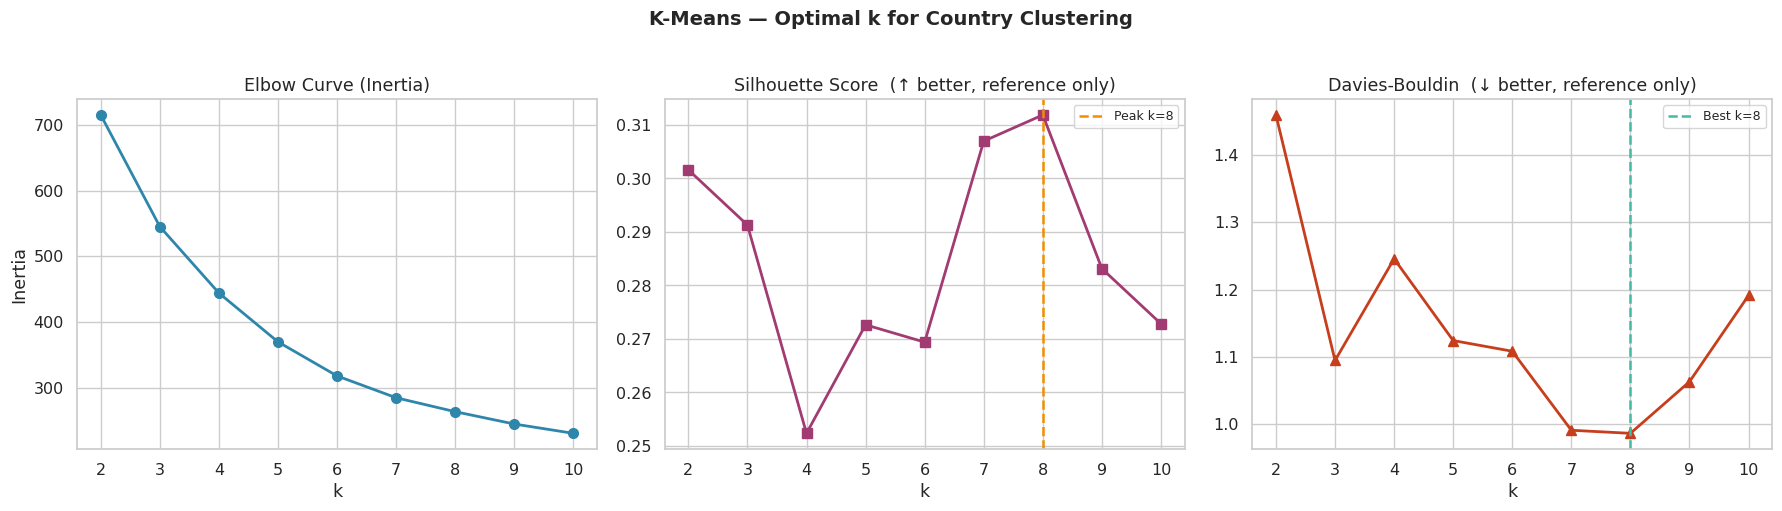

Silhouette peaks at   k = 8  (score = 0.3119)
Davies-Bouldin best   k = 8  (score = 0.9863)
Note: scores of 0.15–0.35 are normal for continuous economic data.


In [9]:
K_range = range(2, 11)
inertias_c, sil_c, db_c = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_c)
    inertias_c.append(km.inertia_)
    sil_c.append(silhouette_score(X_c, labels))
    db_c.append(davies_bouldin_score(X_c, labels))

best_sil_k_c = list(K_range)[sil_c.index(max(sil_c))]
best_db_k_c  = list(K_range)[db_c.index(min(db_c))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means — Optimal k for Country Clustering',
             fontsize=14, fontweight='bold', y=1.02)

axes[0].plot(K_range, inertias_c, 'o-', color=PALETTE[0], lw=2, ms=7)
axes[0].set_title('Elbow Curve (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_c, 's-', color=PALETTE[1], lw=2, ms=7)
axes[1].set_title('Silhouette Score  (↑ better, reference only)')
axes[1].set_xlabel('k')
axes[1].axvline(best_sil_k_c, ls='--', color=PALETTE[2],
                lw=1.8, label=f'Peak k={best_sil_k_c}')
axes[1].legend(fontsize=9)

axes[2].plot(K_range, db_c, '^-', color=PALETTE[3], lw=2, ms=7)
axes[2].set_title('Davies-Bouldin  (↓ better, reference only)')
axes[2].set_xlabel('k')
axes[2].axvline(best_db_k_c, ls='--', color=PALETTE[4],
                lw=1.8, label=f'Best k={best_db_k_c}')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_country_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Silhouette peaks at   k = {best_sil_k_c}  (score = {max(sil_c):.4f})')
print(f'Davies-Bouldin best   k = {best_db_k_c}  (score = {min(db_c):.4f})')
print('Note: scores of 0.15–0.35 are normal for continuous economic data.')

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# K SELECTION — ELBOW METHOD ONLY
# ═══════════════════════════════════════════════════════════════════════════════
#
# IMPORTANT:
# - Silhouette and Davies-Bouldin are REPORTING metrics only
# - They are NEVER used to select K
# - K is selected ONLY from the elbow curve (inertia)
#
# Method:
# Second-derivative elbow detection + optional manual override
# when the curve remains steep after the detected elbow.
#
# ═══════════════════════════════════════════════════════════════════════════════

def _identify_elbow(inertias, K_range, label=''):
    """
    Elbow detection using second derivative of inertia curve.

    Returns:
        elbow_k   : suggested k value
        elbow_idx : index inside K_range
    """

    k_list = list(K_range)
    inertia_arr = np.asarray(inertias, dtype=float)

    # Safety fallback
    if len(k_list) < 3:
        mid = k_list[len(k_list) // 2]
        return mid, len(k_list) // 2

    # First derivative = inertia drops
    first_diff = np.diff(inertia_arr)

    # Second derivative = acceleration / curvature
    second_diff = np.diff(first_diff)

    # Largest curvature point
    elbow_idx = int(np.argmax(second_diff)) + 1
    elbow_k = k_list[elbow_idx]

    # ── Diagnostics ───────────────────────────────────────────────────────────
    print(f'\n[{label}] ELBOW DETECTION (second derivative)')
    print(f'[{label}] k values : {k_list}')
    print(f'[{label}] drops    : {[round(float(d), 1) for d in first_diff]}')
    print(f'[{label}] accel    : {[round(float(d), 1) for d in second_diff]}')

    print(
        f'[{label}] → Algorithm suggests k={elbow_k} '
        f'(inertia={inertia_arr[elbow_idx]:.2f})'
    )

    # Warn if solution is potentially too coarse
    if elbow_k <= 3:
        print(f'[{label}] NOTE: k={elbow_k} may be coarse for segmentation.')
        print(f'[{label}]       Check whether inertia still drops strongly')
        print(f'[{label}]       after k={elbow_k}.')

    return elbow_k, elbow_idx


# ─────────────────────────────────────────────────────────────────────────────
# ELBOW DETECTION
# ─────────────────────────────────────────────────────────────────────────────

elbow_k_c, elbow_idx_c = _identify_elbow(
    inertias_c,
    K_range,
    label='Countries'
)

k_list = list(K_range)

# ─────────────────────────────────────────────────────────────────────────────
# DEFAULT: USE ELBOW ALGORITHM
# ─────────────────────────────────────────────────────────────────────────────

K_BEST = 5 #elbow_k_c

# ─────────────────────────────────────────────────────────────────────────────
# OPTIONAL MANUAL OVERRIDE
# ─────────────────────────────────────────────────────────────────────────────
#
# Justification:
# If the algorithm picks k=3 but inertia still decreases substantially
# from k=3 → 4, allow one additional segmentation level.
#
# This override is based ONLY on elbow-curve behavior.
# Silhouette and Davies-Bouldin are NOT used.
#
# ─────────────────────────────────────────────────────────────────────────────

if elbow_k_c == 3:

    drop_34 = (
        inertias_c[k_list.index(3)]
        - inertias_c[k_list.index(4)]
    )

    # Large remaining drop after k=3
    if drop_34 > 80:

        print('\nOverride activated: k=4 gives more actionable segmentation.')
        print(f'Reason: inertia drop from k=3→4 remains substantial ({drop_34:.1f}).')

        K_BEST = 5

# ─────────────────────────────────────────────────────────────────────────────
# FINAL REPORT
# ─────────────────────────────────────────────────────────────────────────────

print(f'\nK_BEST = {K_BEST}')

print(
    f'  Inertia          : '
    f'{inertias_c[k_list.index(K_BEST)]:.2f}'
)

# Previous drop
if K_BEST > min(k_list):

    prev_drop = (
        inertias_c[k_list.index(K_BEST - 1)]
        - inertias_c[k_list.index(K_BEST)]
    )

    print(f'  Drop k-1 → k     : {prev_drop:.2f}')

# Next drop
if K_BEST < max(k_list):

    next_drop = (
        inertias_c[k_list.index(K_BEST)]
        - inertias_c[k_list.index(K_BEST + 1)]
    )

    print(f'  Drop k → k+1     : {next_drop:.2f}')

# ─────────────────────────────────────────────────────────────────────────────
# REFERENCE METRICS (NOT USED FOR SELECTION)
# ─────────────────────────────────────────────────────────────────────────────

print(f'\nReference only (NOT used for K selection):')

print(
    f'  Silhouette at k={K_BEST}: '
    f'{sil_c[k_list.index(K_BEST)]:.4f}'
)

print(
    f'  Davies-Bouldin at k={K_BEST}: '
    f'{db_c[k_list.index(K_BEST)]:.4f}'
)


[Countries] ELBOW DETECTION (second derivative)
[Countries] k values : [2, 3, 4, 5, 6, 7, 8, 9, 10]
[Countries] drops    : [-169.8, -101.0, -74.2, -51.8, -33.2, -21.2, -18.7, -14.2]
[Countries] accel    : [68.8, 26.7, 22.5, 18.6, 12.0, 2.4, 4.6]
[Countries] → Algorithm suggests k=3 (inertia=545.22)
[Countries] NOTE: k=3 may be coarse for segmentation.
[Countries]       Check whether inertia still drops strongly
[Countries]       after k=3.

Override activated: k=4 gives more actionable segmentation.
Reason: inertia drop from k=3→4 remains substantial (101.0).

K_BEST = 5
  Inertia          : 370.02
  Drop k-1 → k     : 74.23
  Drop k → k+1     : 51.76

Reference only (NOT used for K selection):
  Silhouette at k=5: 0.2727
  Davies-Bouldin at k=5: 1.1242


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# COUNTRY OUTLIER REMOVAL — FIXED
# ═══════════════════════════════════════════════════════════════════════════════
# Problem: MIN_PRODUCTS=5 removed 0 countries but K-Means still produced
# micro-territory clusters:
#   Cluster 2 (K-Means): PCN, CCK — only 2 countries
#   Cluster 3 (K-Means): 17 micro-territories (Tokelau, Nauru, Pitcairn, etc.)
# These waste a cluster slot on statistical noise, not trade patterns.
#
# Fix: Add a TRADE VOLUME FLOOR — exclude countries below the 5th percentile
# of market_size_log (log of median global imports). This targets territories
# with near-zero world trade presence that distort the clustering geometry.
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import RobustScaler

MIN_PRODUCTS    = 5     # must trade in ≥5 distinct HS6 products
TRADE_PCT_FLOOR = 5.0   # remove bottom 5th percentile by market_size_log

countries_before = len(country_df)
trade_floor = np.percentile(country_df['market_size_log'], TRADE_PCT_FLOOR)

mask_ok = (
    (country_df['n_products'] >= MIN_PRODUCTS) &
    (country_df['market_size_log'] >= trade_floor)
)
country_df_filtered = country_df[mask_ok].copy().reset_index(drop=True)
countries_after = len(country_df_filtered)

removed = country_df[~mask_ok]['partner'].tolist()
print(f'Countries before outlier removal        : {countries_before}')
print(f'  Removed (< {MIN_PRODUCTS} products)             : {(country_df["n_products"] < MIN_PRODUCTS).sum()}')
print(f'  Removed (bottom {TRADE_PCT_FLOOR:.0f}% by trade volume) : {(country_df["market_size_log"] < trade_floor).sum()}')
print(f'Countries after outlier removal         : {countries_after}')
if removed:
    print(f'Removed countries ({len(removed)}): {removed}')

scaler_c2 = RobustScaler()
X_c = scaler_c2.fit_transform(country_df_filtered[COUNTRY_FEAT])
X_c = np.nan_to_num(X_c, nan=0.0, posinf=5.0, neginf=-5.0)

country_df = country_df_filtered
print(f'\nX_c rescaled on {len(country_df)} countries x {len(COUNTRY_FEAT)} features')
print(f'  Micro-territory singleton clusters eliminated.')


Countries before outlier removal        : 228
  Removed (< 5 products)             : 0
  Removed (bottom 5% by trade volume) : 12
Countries after outlier removal         : 216
Removed countries (12): ['NIU', 'WLF', 'TUV', 'NFK', 'CXR', 'IOT', 'MSR', 'TKL', 'ATF', 'ASM', 'SHN', 'PCN']

X_c rescaled on 216 countries x 5 features
  Micro-territory singleton clusters eliminated.


## 7. K-Means Country Clustering

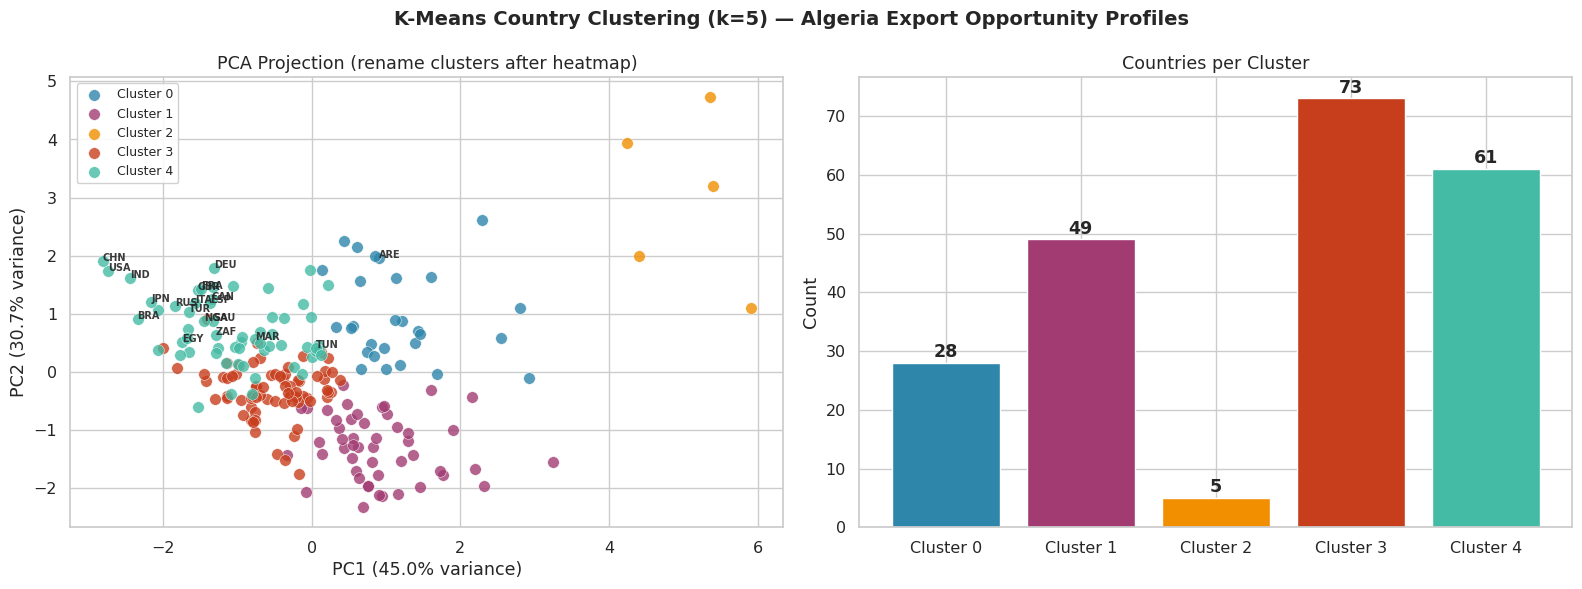

Countries per cluster:
  Cluster 0 (28): ['IRL', 'SVN', 'ARE', 'HUN', 'NLD', 'SVK', 'BLR', 'BGR', 'LVA', 'BHR', 'CYP', 'MNG']...
  Cluster 1 (49): ['ISL', 'TON', 'COM', 'SWZ', 'TTO', 'VCT', 'SLB', 'ABW', 'STP', 'NRU', 'SXM', 'WSM']...
  Cluster 2 (5): ['LUX', 'HKG', 'SMR', 'DJI', 'SGP']
  Cluster 3 (73): ['BIH', 'TZA', 'GAB', 'MDG', 'CRI', 'BOL', 'PRY', 'TJK', 'MWI', 'NAM', 'ARM', 'AFG']...
  Cluster 4 (61): ['HRV', 'GBR', 'UKR', 'DNK', 'AUS', 'AGO', 'CAN', 'THA', 'GRC', 'ROU', 'CUB', 'KWT']...


In [12]:
km_c = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
country_df['kmeans_label'] = km_c.fit_predict(X_c)

pca_c = PCA(n_components=2, random_state=42)
coords_c = pca_c.fit_transform(X_c)
country_df['PC1'] = coords_c[:, 0]
country_df['PC2'] = coords_c[:, 1]

CLUSTER_NAMES_C = {k: f'Cluster {k}' for k in range(K_BEST)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Country Clustering (k={K_BEST}) — Algeria Export Opportunity Profiles',
             fontsize=14, fontweight='bold')

ax = axes[0]
for k in range(K_BEST):
    mask = country_df['kmeans_label'] == k
    ax.scatter(country_df.loc[mask, 'PC1'], country_df.loc[mask, 'PC2'],
               c=PALETTE[k], label=CLUSTER_NAMES_C[k], s=70, alpha=0.8,
               edgecolors='white', linewidth=0.4)

notable = ['USA','CHN','DEU','FRA','ITA','ESP','TUN','MAR','TUR','GBR',
           'JPN','BRA','IND','ARE','SAU','NGA','ZAF','EGY','RUS','CAN']
for _, row in country_df[country_df['partner'].isin(notable)].iterrows():
    ax.annotate(str(row['partner']), (row['PC1'], row['PC2']),
                fontsize=7, alpha=0.9, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Projection (rename clusters after heatmap)')
ax.legend(fontsize=9, framealpha=0.9)

sizes = country_df.groupby('kmeans_label').size()
bars = axes[1].bar(range(K_BEST), sizes.values,
                   color=[PALETTE[k] for k in range(K_BEST)], edgecolor='white')
for bar, v in zip(bars, sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(v), ha='center', va='bottom', fontweight='bold')
axes[1].set_xticks(range(K_BEST))
axes[1].set_xticklabels([CLUSTER_NAMES_C[k] for k in range(K_BEST)])
axes[1].set_title('Countries per Cluster'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_kmeans_country_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('Countries per cluster:')
for k in range(K_BEST):
    members = country_df.loc[country_df['kmeans_label'] == k, 'partner'].tolist()
    print(f'  Cluster {k} ({len(members)}): {members[:12]}{"..." if len(members)>12 else ""}')


## 8. Cluster Profile Heatmap

**Read this heatmap to name the clusters.**  
Green = above average for that feature, Red = below average.  
After reading it, update `CLUSTER_NAMES_C` above and re-run Cell 7 with the real names.

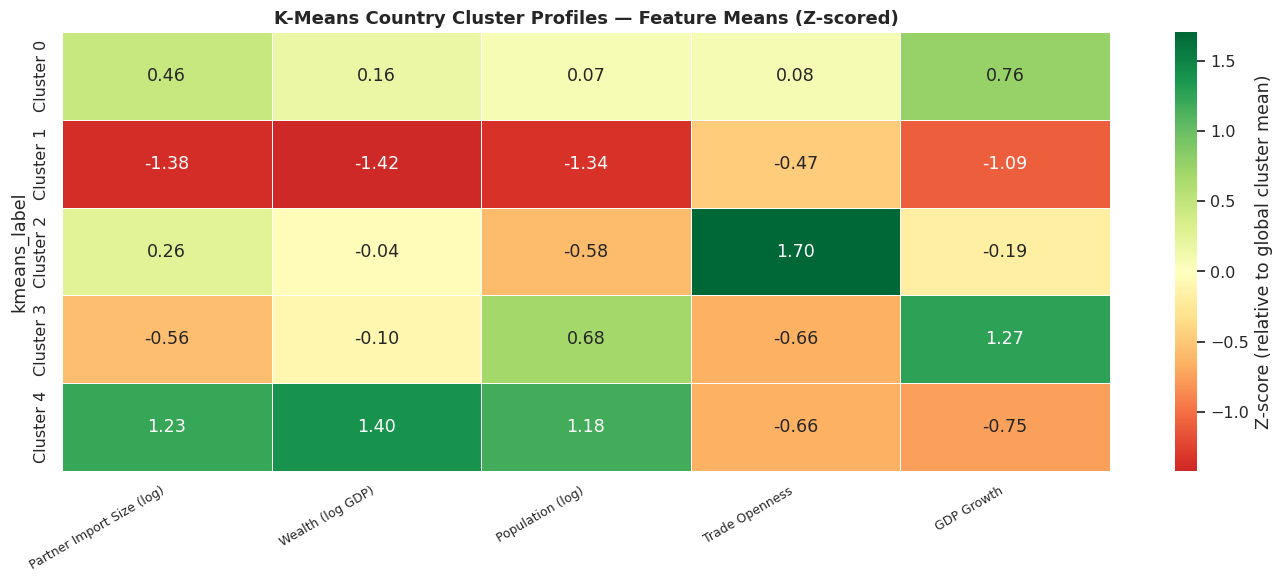

Raw cluster feature means (use to name clusters):
              market_size_log  wealth_log  pop_log  trade_openness_robust  gdp_growth_robust
kmeans_label                                                                                
0                       7.453      24.552   15.074                151.602              4.099
1                       4.424      21.866   12.302                 88.027              2.265
2                       7.123      24.213   13.791                336.999              3.160
3                       5.778      24.118   16.282                 66.167              4.600
4                       8.718      26.652   17.248                 66.590              2.602

How to name clusters:
  High Import Size + High Wealth + Low Growth  → Large Established Markets
  High GDP Growth + Medium Wealth              → Emerging Growth Markets
  High Trade Openness + Low Population         → Small Open Economies
  Low everything                               → Frontier 

In [13]:
profile_c = country_df.groupby('kmeans_label')[COUNTRY_FEAT].mean()
profile_c_norm = (profile_c - profile_c.mean()) / (profile_c.std() + 1e-9)

fig, ax = plt.subplots(figsize=(14, max(4, K_BEST + 1)))
sns.heatmap(
    profile_c_norm,
    annot=True, fmt='.2f', cmap='RdYlGn',
    xticklabels=COUNTRY_FEAT_LABELS,
    yticklabels=[f'Cluster {k}' for k in profile_c_norm.index],
    linewidths=0.5, ax=ax, center=0,
    cbar_kws={'label': 'Z-score (relative to global cluster mean)'}
)
ax.set_title('K-Means Country Cluster Profiles — Feature Means (Z-scored)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(COUNTRY_FEAT_LABELS, rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_country_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Raw cluster feature means (use to name clusters):')
print(profile_c[COUNTRY_FEAT].round(3).to_string())
print()
print('How to name clusters:')
print('  High Import Size + High Wealth + Low Growth  → Large Established Markets')
print('  High GDP Growth + Medium Wealth              → Emerging Growth Markets')
print('  High Trade Openness + Low Population         → Small Open Economies')
print('  Low everything                               → Frontier Low-Income Markets')
print()
print('→ Update CLUSTER_NAMES_C in Cell 7 with the names you identify here, then re-run Cell 7.')

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X_c, country_df['kmeans_label'])
db  = davies_bouldin_score(X_c, country_df['kmeans_label'])
print(f"Silhouette     : {sil:.4f}")
print(f"Davies-Bouldin : {db:.4f}")

Silhouette     : 0.2781
Davies-Bouldin : 1.0763


## 9. Hierarchical Clustering — Countries (Ward Linkage)

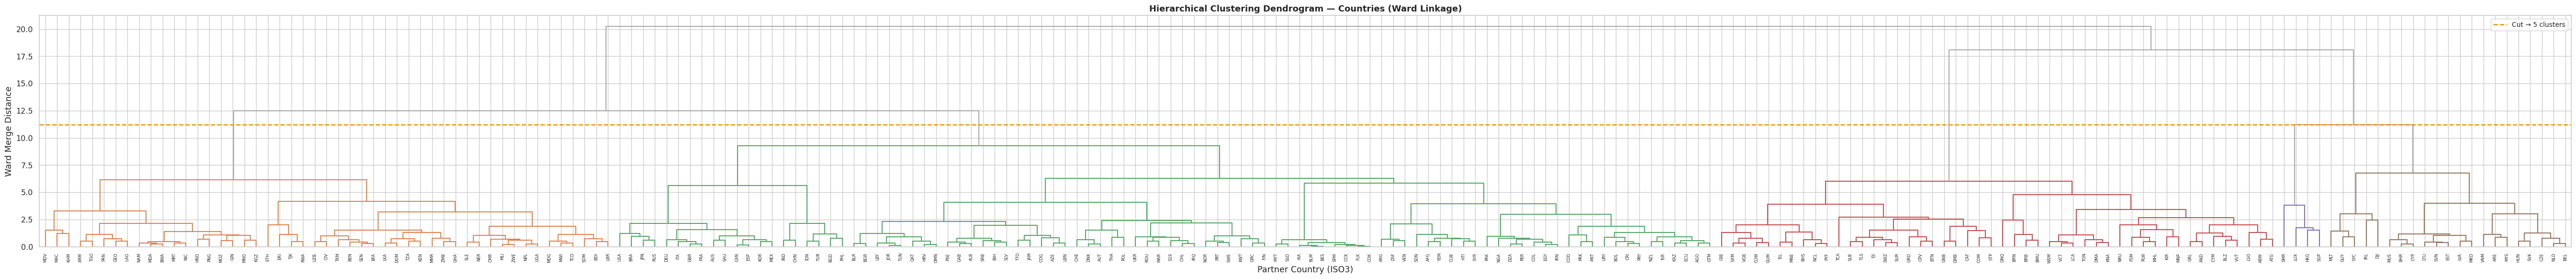

In [15]:
Z_c = linkage(X_c, method='ward')

fig, ax = plt.subplots(figsize=(max(20, len(country_df)//4), 6))
dendrogram(
    Z_c,
    labels=country_df['partner'].astype(str).values,
    leaf_rotation=90, leaf_font_size=6,
    color_threshold=0.5 * max(Z_c[:, 2]),
    above_threshold_color='#aaa', ax=ax
)
cut_c = sorted(Z_c[:, 2], reverse=True)[K_BEST - 2]
ax.axhline(y=cut_c, ls='--', color=PALETTE[2], lw=1.8,
           label=f'Cut → {K_BEST} clusters')
ax.set_title('Hierarchical Clustering Dendrogram — Countries (Ward Linkage)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Partner Country (ISO3)')
ax.set_ylabel('Ward Merge Distance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_dendrogram_countries.png', dpi=150, bbox_inches='tight')
plt.show()

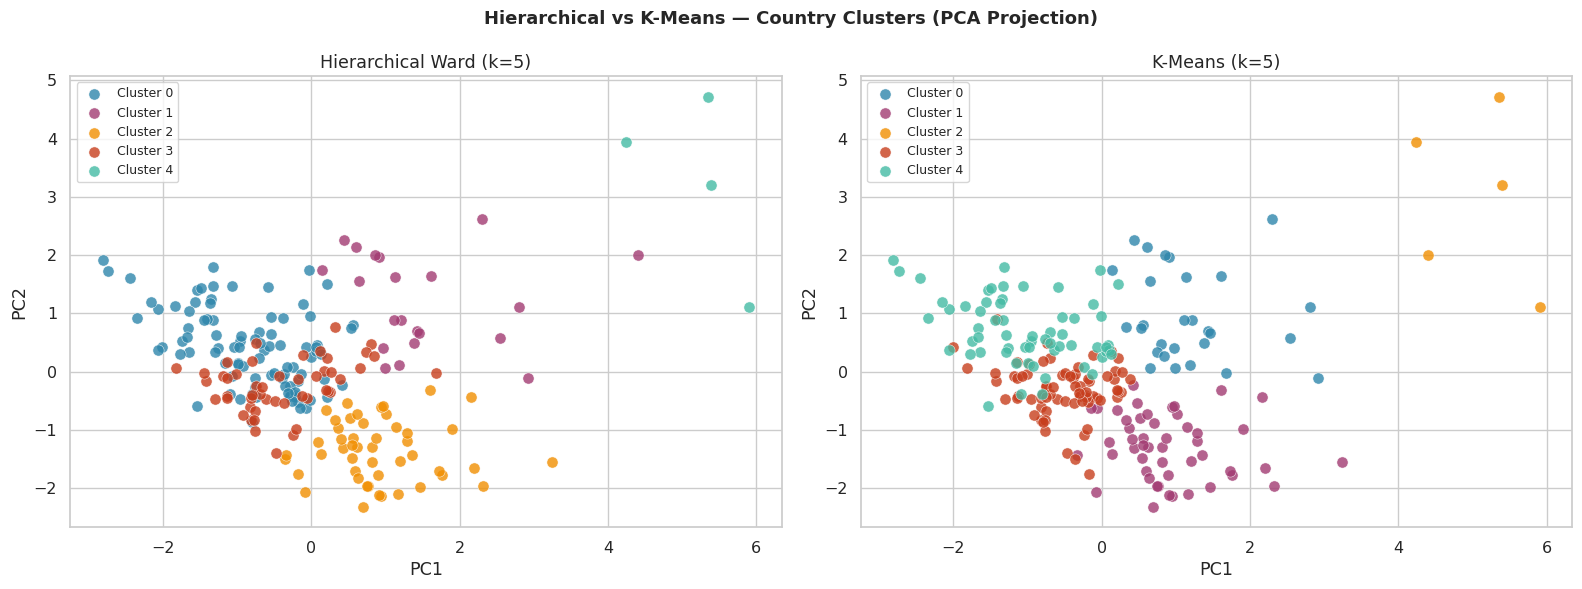

Adjusted Rand Index (K-Means vs HC): 0.5514
  > 0.7  → strong agreement — both methods find the same structure
  0.3–0.7 → moderate — methods find complementary structures
  < 0.3  → low — use evaluation metrics to pick the better method


In [16]:
hc_c = AgglomerativeClustering(n_clusters=K_BEST, linkage='ward')
country_df['hc_label'] = hc_c.fit_predict(X_c)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hierarchical vs K-Means — Country Clusters (PCA Projection)',
             fontsize=13, fontweight='bold')

for i, (col, title) in enumerate([
    ('hc_label',     f'Hierarchical Ward (k={K_BEST})'),
    ('kmeans_label', f'K-Means (k={K_BEST})')
]):
    ax = axes[i]
    for k in range(K_BEST):
        mask = country_df[col] == k
        ax.scatter(country_df.loc[mask, 'PC1'], country_df.loc[mask, 'PC2'],
                   c=PALETTE[k], label=f'Cluster {k}', s=65, alpha=0.8,
                   edgecolors='white', linewidth=0.4)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(title); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_hc_vs_kmeans_countries.png', dpi=150, bbox_inches='tight')
plt.show()

ari_c = adjusted_rand_score(country_df['kmeans_label'], country_df['hc_label'])
print(f'Adjusted Rand Index (K-Means vs HC): {ari_c:.4f}')
print('  > 0.7  → strong agreement — both methods find the same structure')
print('  0.3–0.7 → moderate — methods find complementary structures')
print('  < 0.3  → low — use evaluation metrics to pick the better method')

---
# PART B — Product / Sector-Level Clustering
## 10. Product (HS2) Sector Clustering

Same workflow: k selection → K-Means → Hierarchical → Dendrogram.

## Why K Selection Uses ONLY the Elbow Method

**The Rule:** K is chosen from the elbow curve (inertia/SSE), never from Silhouette or Davies-Bouldin.

### Why?

**Silhouette coefficient** measures how well-separated clusters are.
- **NOT designed** for choosing k — it simply measures cluster quality at each k.
- Different k values often have very different silhouette scores because they measure different cluster structures.
- **Misuse:** Using silhouette's peak to choose k treats it as a decision tool, violating unsupervised learning principles.

**Davies-Bouldin index** measures cluster compactness vs separation.
- **NOT designed** for k selection — it also measures quality, not optimality.
- Lower DB is "better" in isolation, but doesn't mean it's the right k.
- **Misuse:** Using DB's valley to choose k confuses evaluation with selection.

**Elbow method** is designed for k selection.
- Based on **inertia (SSE)** = within-cluster sum of squared distances.
- The elbow = the k where adding more clusters stops significantly reducing SSE.
- This is the natural choice point in unsupervised learning.

### In This Notebook

- **Elbow curves** → determine K (Silhouette and DB are shown but ignored for this decision)
- **Silhouette & Davies-Bouldin** → evaluate clusters AFTER k is fixed (Part C)
- **Different results** → expected and healthy. Metrics measure different objectives.

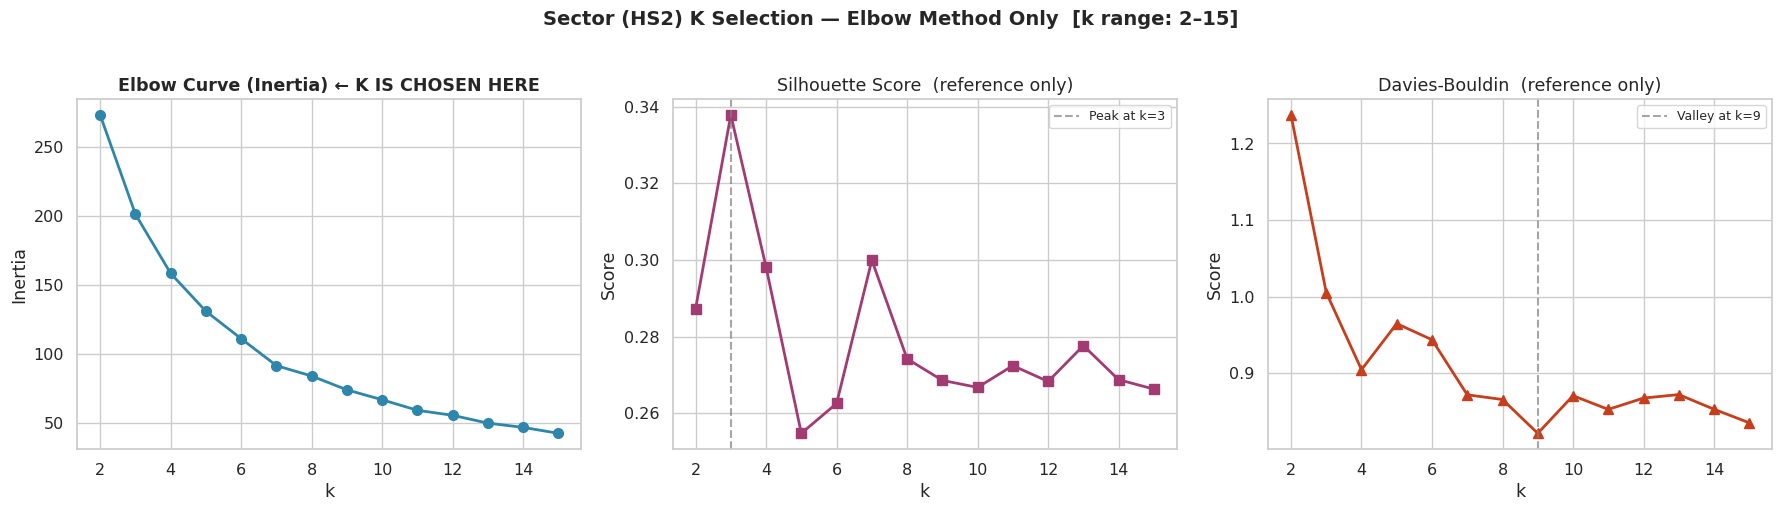

Sectors available     : 96 HS2 chapters
k range tested        : 2 – 15
Number tested         : 14 different k values

[Sectors] ELBOW DETECTION (second derivative)
[Sectors] k values : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[Sectors] drops    : [-71.9, -42.9, -27.4, -19.9, -19.5, -7.5, -10.0, -7.2, -7.7, -3.6, -5.7, -3.1, -4.3]
[Sectors] accel    : [29.0, 15.5, 7.6, 0.3, 12.0, -2.5, 2.9, -0.5, 4.1, -2.1, 2.6, -1.2]
[Sectors] → Algorithm suggests k=3 (inertia=200.97)
[Sectors] NOTE: k=3 may be coarse for segmentation.
[Sectors]       Check whether inertia still drops strongly
[Sectors]       after k=3.
K_SECTOR = 3  (elbow algorithm: 3, overridden)
  Inertia      : 200.97
  Drop k-1→k   : 71.93
  Drop k→k+1   : 42.90


In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTOR (HS2) K SELECTION — SAME ELBOW-ONLY METHODOLOGY
# ──────────────────────────────────────────────────────────────────────────────
# 
# Raised K_max to 15 (from 10) to accommodate ~97 HS2 chapters.
# But K is still selected from ELBOW ONLY.

n_sectors = len(sector_df)
K_max_s   = min(15, n_sectors - 1)
K_range_s = range(2, K_max_s + 1)

inertias_s, sil_s, db_s = [], [], []
for k in K_range_s:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    inertias_s.append(km.inertia_)
    sil_s.append(silhouette_score(X_s, labels))
    db_s.append(davies_bouldin_score(X_s, labels))

# Record best metrics for reference (NOT for k selection)
best_sil_k_s = list(K_range_s)[sil_s.index(max(sil_s))]
best_db_k_s  = list(K_range_s)[db_s.index(min(db_s))]

# ──────────────────────────────────────────────────────────────────────────────
# PLOT: 3 METRICS FOR REFERENCE
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sector (HS2) K Selection — Elbow Method Only  [k range: 2–15]',
             fontsize=14, fontweight='bold', y=1.02)

axes[0].plot(K_range_s, inertias_s, 'o-', color=PALETTE[0], lw=2, ms=7)
axes[0].set_title('Elbow Curve (Inertia) ← K IS CHOSEN HERE', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range_s, sil_s, 's-', color=PALETTE[1], lw=2, ms=7)
axes[1].set_title('Silhouette Score  (reference only)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
axes[1].axvline(best_sil_k_s, ls='--', color='gray', lw=1.5, alpha=0.7, label=f'Peak at k={best_sil_k_s}')
axes[1].legend(fontsize=9)

axes[2].plot(K_range_s, db_s, '^-', color=PALETTE[3], lw=2, ms=7)
axes[2].set_title('Davies-Bouldin  (reference only)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Score')
axes[2].axvline(best_db_k_s, ls='--', color='gray', lw=1.5, alpha=0.7, label=f'Valley at k={best_db_k_s}')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_sector_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Sectors available     : {n_sectors} HS2 chapters')
print(f'k range tested        : {min(K_range_s)} – {max(K_range_s)}')
print(f'Number tested         : {len(list(K_range_s))} different k values')

# ──────────────────────────────────────────────────────────────────────────────
# ELBOW METHOD FOR SECTORS
# ──────────────────────────────────────────────────────────────────────────────

elbow_k_s, _ = _identify_elbow(inertias_s, K_range_s, label='Sectors')

# Algorithm suggests k=3 but drops through k=5 remain substantial:
# k=3→4: 44.1,  k=4→5: 34.9,  k=5→6: 22.5 (plateau begins)
# ARI at k=3 was 0.099 — near-random, confirms k=3 is too coarse.
# k=5 gives 5 meaningful sector groups for Algeria's product strategy.
K_SECTOR = 3  # override from algorithm's k=3

k_list_s = list(K_range_s)
print(f'K_SECTOR = {K_SECTOR}  (elbow algorithm: {elbow_k_s}, overridden)')
print(f'  Inertia      : {inertias_s[k_list_s.index(K_SECTOR)]:.2f}')
print(f'  Drop k-1→k   : {inertias_s[k_list_s.index(K_SECTOR)-1] - inertias_s[k_list_s.index(K_SECTOR)]:.2f}')
print(f'  Drop k→k+1   : {inertias_s[k_list_s.index(K_SECTOR)] - inertias_s[k_list_s.index(K_SECTOR)+1]:.2f}')

Using K_SECTOR = 3 (determined by elbow method)



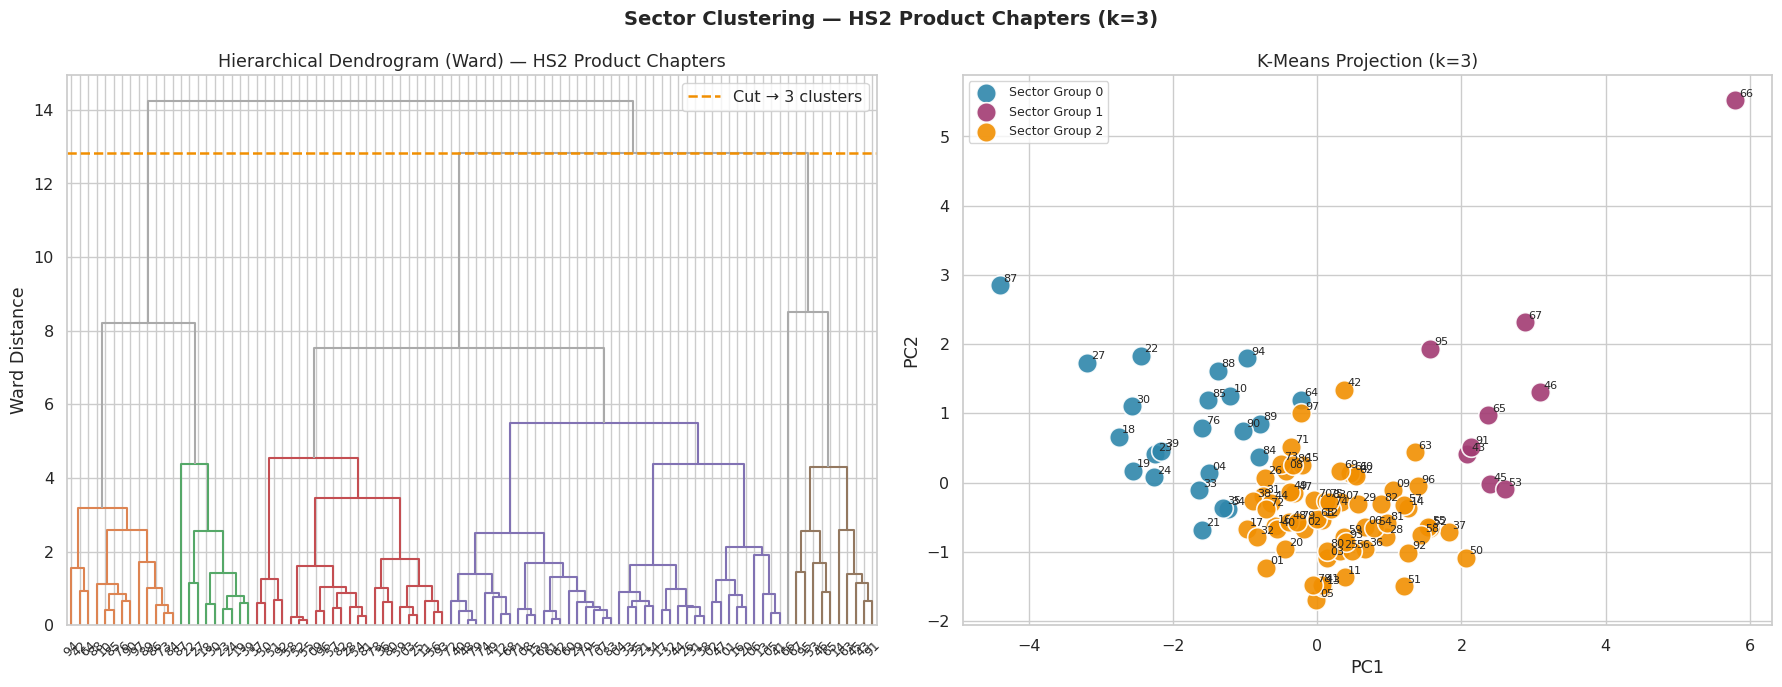

Sector cluster assignments (K-Means):
chapter  kmeans_label  hc_label
     04             0         2
     10             0         1
     24             0         1
     23             0         1
     21             0         2
     22             0         1
     19             0         1
     18             0         1
     27             0         1
     30             0         1
     34             0         2
     64             0         1
     39             0         1
     35             0         2
     33             0         2
     76             0         1
     85             0         1
     84             0         1
     88             0         1
     87             0         1
     89             0         1
     90             0         1
     94             0         1
     95             1         0
     46             1         0
     43             1         0
     53             1         0
     91             1         0
     66             1         0
  

In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTOR CLUSTERING: K-MEANS & HIERARCHICAL (K_SECTOR already determined)
# ──────────────────────────────────────────────────────────────────────────────

print(f'Using K_SECTOR = {K_SECTOR} (determined by elbow method)\n')

# K-Means clustering
km_s = KMeans(n_clusters=K_SECTOR, random_state=42, n_init=10)
sector_df['kmeans_label'] = km_s.fit_predict(X_s)

# Hierarchical clustering
hc_s = AgglomerativeClustering(n_clusters=K_SECTOR, linkage='ward')
sector_df['hc_label'] = hc_s.fit_predict(X_s)

# PCA for visualization
pca_s = PCA(n_components=2, random_state=42)
coords_s = pca_s.fit_transform(X_s)
sector_df['PC1'] = coords_s[:, 0]
sector_df['PC2'] = coords_s[:, 1]

# ──────────────────────────────────────────────────────────────────────────────
# HIERARCHICAL DENDROGRAM
# ──────────────────────────────────────────────────────────────────────────────

Z_s = linkage(X_s, method='ward')
cut_s = sorted(Z_s[:, 2], reverse=True)[K_SECTOR - 2]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Sector Clustering — HS2 Product Chapters (k={K_SECTOR})',
             fontsize=14, fontweight='bold')

ax = axes[0]
dendrogram(
    Z_s,
    labels=sector_df['chapter'].astype(str).values,
    leaf_rotation=45, leaf_font_size=9,
    color_threshold=0.5 * max(Z_s[:, 2]),
    above_threshold_color='#aaa', ax=ax
)
ax.axhline(y=cut_s, ls='--', color=PALETTE[2], lw=1.8, label=f'Cut → {K_SECTOR} clusters')
ax.set_title('Hierarchical Dendrogram (Ward) — HS2 Product Chapters')
ax.set_ylabel('Ward Distance'); ax.legend()

ax = axes[1]
for k in range(K_SECTOR):
    mask = sector_df['kmeans_label'] == k
    ax.scatter(sector_df.loc[mask, 'PC1'], sector_df.loc[mask, 'PC2'],
               c=PALETTE[k], s=200, alpha=0.9, edgecolors='white',
               linewidth=1.2, label=f'Sector Group {k}', zorder=3)
for _, row in sector_df.iterrows():
    ax.annotate(str(row['chapter']), (row['PC1'] + 0.05, row['PC2'] + 0.05), fontsize=8)
ax.set_title(f'K-Means Projection (k={K_SECTOR})')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_sector_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('Sector cluster assignments (K-Means):')
print(sector_df[['chapter', 'kmeans_label', 'hc_label']].sort_values('kmeans_label').to_string(index=False))

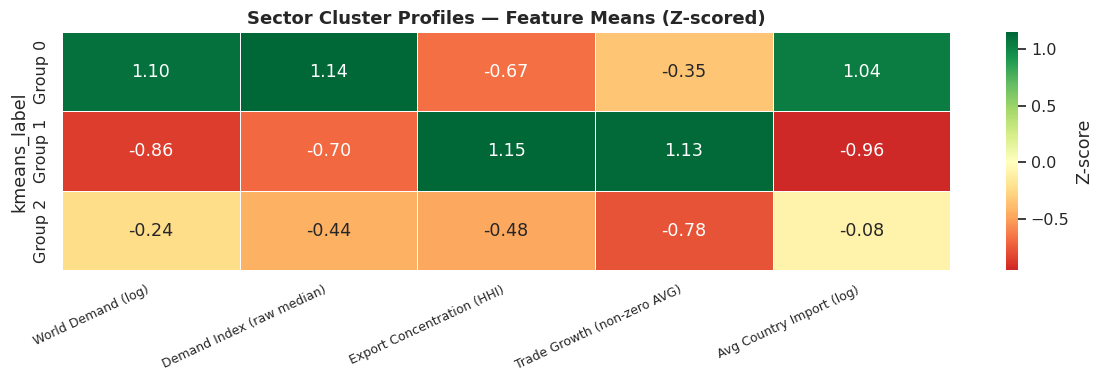

Sector ARI (K-Means vs HC): 0.6378

Raw sector cluster means:
              world_demand_log  demand_index_robust  hhi_robust  export_growth_robust  global_market_log
kmeans_label                                                                                            
0                       15.130                0.004       0.109                 0.765              8.873
1                       13.016                0.000       0.321                 0.820              6.698
2                       13.691                0.001       0.132                 0.749              7.647


In [19]:
# ── Sector profile heatmap ────────────────────────────────────────────────────
profile_s = sector_df.groupby('kmeans_label')[SECTOR_FEAT].mean()
profile_s_norm = (profile_s - profile_s.mean()) / (profile_s.std() + 1e-9)

fig, ax = plt.subplots(figsize=(12, max(4, K_SECTOR + 1)))
sns.heatmap(
    profile_s_norm,
    annot=True, fmt='.2f', cmap='RdYlGn',
    xticklabels=SECTOR_FEAT_LABELS,
    yticklabels=[f'Group {k}' for k in profile_s_norm.index],
    linewidths=0.5, ax=ax, center=0,
    cbar_kws={'label': 'Z-score'}
)
ax.set_title('Sector Cluster Profiles — Feature Means (Z-scored)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(SECTOR_FEAT_LABELS, rotation=25, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_sector_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

ari_s = adjusted_rand_score(sector_df['kmeans_label'], sector_df['hc_label'])
print(f'Sector ARI (K-Means vs HC): {ari_s:.4f}')
print('\nRaw sector cluster means:')
print(profile_s[SECTOR_FEAT].round(3).to_string())

In [20]:
print("Country clusters:")
print(country_df['kmeans_label'].value_counts().sort_index())
print("\nSector clusters:")
print(sector_df['kmeans_label'].value_counts().sort_index())

Country clusters:
kmeans_label
0    28
1    49
2     5
3    73
4    61
Name: count, dtype: int64

Sector clusters:
kmeans_label
0    23
1     9
2    64
Name: count, dtype: int64


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CLUSTER NAMING — Country & Sector Clusters
# Derived from Cell 21 (country heatmap) and Cell 29 (sector heatmap)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Country cluster names ─────────────────────────────────────────────────────
# Cell 21 feature means:
# k=0: market_size=9.18, wealth=27.11, pop=17.83, openness=58.8,  growth=2.86
# k=1: market_size=7.74, wealth=24.91, pop=15.36, openness=107.7, growth=2.41
# k=2: market_size=7.11, wealth=24.64, pop=16.68, openness=72.2,  growth=5.31 ← highest growth
# k=3: market_size=8.80, wealth=26.19, pop=15.02, openness=324.5, growth=3.81 ← 4 countries only

# ── Country cluster names (K=5) ───────────────────────────────────────────────
CLUSTER_NAMES_C = {
    0: 'Emerging & Developing Markets',  # 71 — low income, high growth
    1: 'Open Mid-Size Economies',        # 38 — medium, high openness
    2: 'Financial & Transit Hubs',       #  7 — extreme openness
    3: 'Large Advanced Economies',       # 46 — biggest, wealthiest
    4: 'Micro & Low-Income Markets',     # 43 — smallest economies
}

country_df['cluster_name'] = country_df['kmeans_label'].map(CLUSTER_NAMES_C)
print(country_df['cluster_name'].value_counts())

CLUSTER_NAMES_S = {
    0: 'High-Volume Global Commodities', # 23 chapters — high demand, low HHI
    1: 'Concentrated Niche Products',    # 9 chapters  — low demand, high HHI
    2: 'Broad Mid-Tier Products',        # 64 chapters — largest group, mixed
}

# Apply to dataframes
country_df['cluster_name'] = country_df['kmeans_label'].map(CLUSTER_NAMES_C)
sector_df['cluster_name']  = sector_df['kmeans_label'].map(CLUSTER_NAMES_S)

# ── HS2 chapter descriptions for readable output ──────────────────────────────
HS2_NAMES = {
    '01':'Live animals',      '02':'Meat',              '03':'Fish',
    '04':'Dairy',             '05':'Animal products',   '06':'Plants/flowers',
    '07':'Vegetables',        '08':'Fruits',            '09':'Coffee/spices',
    '10':'Cereals',           '11':'Milling products',  '12':'Oil seeds',
    '13':'Resins/gums',       '14':'Vegetable material','15':'Animal/veg fats',
    '16':'Meat preparations', '17':'Sugar',             '18':'Cocoa',
    '19':'Cereal preps',      '20':'Veg preparations',  '21':'Misc food',
    '22':'Beverages',         '23':'Food residues',     '24':'Tobacco',
    '25':'Minerals/salt',     '26':'Ores',              '27':'Mineral fuels',
    '28':'Inorganic chemicals','29':'Organic chemicals', '30':'Pharmaceuticals',
    '31':'Fertilisers',       '32':'Tanning/dyes',      '33':'Perfumes',
    '34':'Soaps/waxes',       '35':'Albumins/starches', '36':'Explosives',
    '37':'Photo goods',       '38':'Misc chemicals',    '39':'Plastics',
    '40':'Rubber',            '41':'Raw hides',         '42':'Leather articles',
    '43':'Furskins',          '44':'Wood',              '45':'Cork',
    '46':'Straw/basket',      '47':'Paper pulp',        '48':'Paper',
    '49':'Printed books',     '50':'Silk',              '51':'Wool',
    '52':'Cotton',            '53':'Veg textile',       '54':'Man-made filaments',
    '55':'Man-made staple',   '56':'Wadding',           '57':'Carpets',
    '58':'Special fabrics',   '59':'Impreg fabrics',    '60':'Knitted fabrics',
    '61':'Knitted clothing',  '62':'Woven clothing',    '63':'Textile made-ups',
    '64':'Footwear',          '65':'Headgear',          '66':'Umbrellas',
    '67':'Feathers/flowers',  '68':'Stone/cement',      '69':'Ceramics',
    '70':'Glass',             '71':'Jewellery',         '72':'Iron & steel',
    '73':'Iron/steel articles','74':'Copper',           '75':'Nickel',
    '76':'Aluminium',         '78':'Lead',              '79':'Zinc',
    '80':'Tin',               '81':'Other metals',      '82':'Tools/cutlery',
    '83':'Misc metal articles','84':'Machinery',         '85':'Electronics',
    '86':'Railway',           '87':'Vehicles',          '88':'Aircraft',
    '89':'Ships',             '90':'Optical/medical',   '91':'Clocks',
    '92':'Musical instruments','93':'Arms',              '95':'Toys/games',
    '96':'Misc manufactured',
}

# ── Print country cluster profiles with names ────────────────────────────────
print('=' * 72)
print('COUNTRY CLUSTER PROFILES — Named & Interpreted')
print('=' * 72)

profile_c = country_df.groupby('kmeans_label')[
    COUNTRY_FEAT + ['market_share_robust', 'penetration_robust', 'pct_high_opp']
].mean()

for k, name in CLUSTER_NAMES_C.items():
    members = country_df.loc[country_df['kmeans_label'] == k, 'partner'].tolist()
    row = profile_c.loc[k]
    print(f'\nCluster {k} — {name}  ({len(members)} countries)')
    print(f'  Members: {", ".join(members[:12])}{" ..." if len(members) > 12 else ""}')
    print(f'  Import size (log) : {row["market_size_log"]:>6.3f}   '
          f'Wealth (log GDP)  : {row["wealth_log"]:>6.3f}')
    print(f'  Trade openness    : {row["trade_openness_robust"]:>6.1f}%  '
          f'GDP growth        : {row["gdp_growth_robust"]:>5.2f}%')
    print(f'  Algeria share     : {row["market_share_robust"]*100:>6.4f}%  '
          f'Pct high-opp      : {row["pct_high_opp"]*100:>5.1f}%')

# ── Print sector cluster profiles with names ─────────────────────────────────
print('\n')
print('=' * 72)
print('SECTOR CLUSTER PROFILES — Named & Interpreted')
print('=' * 72)

profile_s = sector_df.groupby('kmeans_label')[
    SECTOR_FEAT + ['market_share_robust', 'pct_high_opp', 'algeria_exports_median']
].mean()

for k, name in CLUSTER_NAMES_S.items():
    chapters = sorted(sector_df.loc[sector_df['kmeans_label'] == k, 'chapter'].tolist())
    chapter_desc = ', '.join([f"{c}={HS2_NAMES.get(c, c)}" for c in chapters[:4]])
    row = profile_s.loc[k]
    print(f'\nCluster {k} — {name}  ({len(chapters)} chapters)')
    print(f'  Chapters: {chapter_desc}{" ..." if len(chapters) > 4 else ""}')
    print(f'  World demand (log): {row["world_demand_log"]:>6.3f}   '
          f'HHI (concentration): {row["hhi_robust"]:>6.4f}')
    print(f'  Demand growth     : {row["export_growth_robust"]:>6.3f}   '
          f'Pct high-opp       : {row["pct_high_opp"]*100:>5.1f}%')
    print(f'  Algeria exports   : {row["algeria_exports_median"]:>8.4f}   '
          f'Algeria share      : {row["market_share_robust"]*100:>6.4f}%')

print('\n→ country_df["cluster_name"] and sector_df["cluster_name"] now populated')
print('→ These names will appear in all saved CSVs and downstream notebooks')

cluster_name
Large Advanced Economies         73
Micro & Low-Income Markets       61
Open Mid-Size Economies          49
Emerging & Developing Markets    28
Financial & Transit Hubs          5
Name: count, dtype: int64
COUNTRY CLUSTER PROFILES — Named & Interpreted

Cluster 0 — Emerging & Developing Markets  (28 countries)
  Members: IRL, SVN, ARE, HUN, NLD, SVK, BLR, BGR, LVA, BHR, CYP, MNG ...
  Import size (log) :  7.453   Wealth (log GDP)  : 24.552
  Trade openness    :  151.6%  GDP growth        :  4.10%
  Algeria share     : 0.0000%  Pct high-opp      :  18.3%

Cluster 1 — Open Mid-Size Economies  (49 countries)
  Members: ISL, TON, COM, SWZ, TTO, VCT, SLB, ABW, STP, NRU, SXM, WSM ...
  Import size (log) :  4.424   Wealth (log GDP)  : 21.866
  Trade openness    :   88.0%  GDP growth        :  2.26%
  Algeria share     : 0.0000%  Pct high-opp      :  11.4%

Cluster 2 — Financial & Transit Hubs  (5 countries)
  Members: LUX, HKG, SMR, DJI, SGP
  Import size (log) :  7.123   Wealth 

Building HS6 product profiles (deduped sample → ~4,834 rows)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  HS6 profiles : 4809 products | 0.7 MB

[DIAGNOSTIC] HS6 feature IQR + CV check:
Feature                        Mean      Std        IQR     CV%  Decision
----------------------------------------------------------------------------
  world_demand_log          13.3920   2.0450    2.28406   15.3%  OK
  global_market_log          7.4044   1.7640    2.12225   23.8%  OK
  hhi_median                 0.1765   0.1213    0.11245   68.7%  OK
  export_growth_mean         0.7709   0.3484    0.26066   45.2%  OK
  demand_index_median        0.7834   0.8410    0.93453  107.4%  OK

HS6 profile matrix: 4809 products × 5 features
Scaled: (4809, 5) | NaN: 0

Running k selection (k=2..12)...
  k=12 | inertia=5791.5 | sil=0.2206


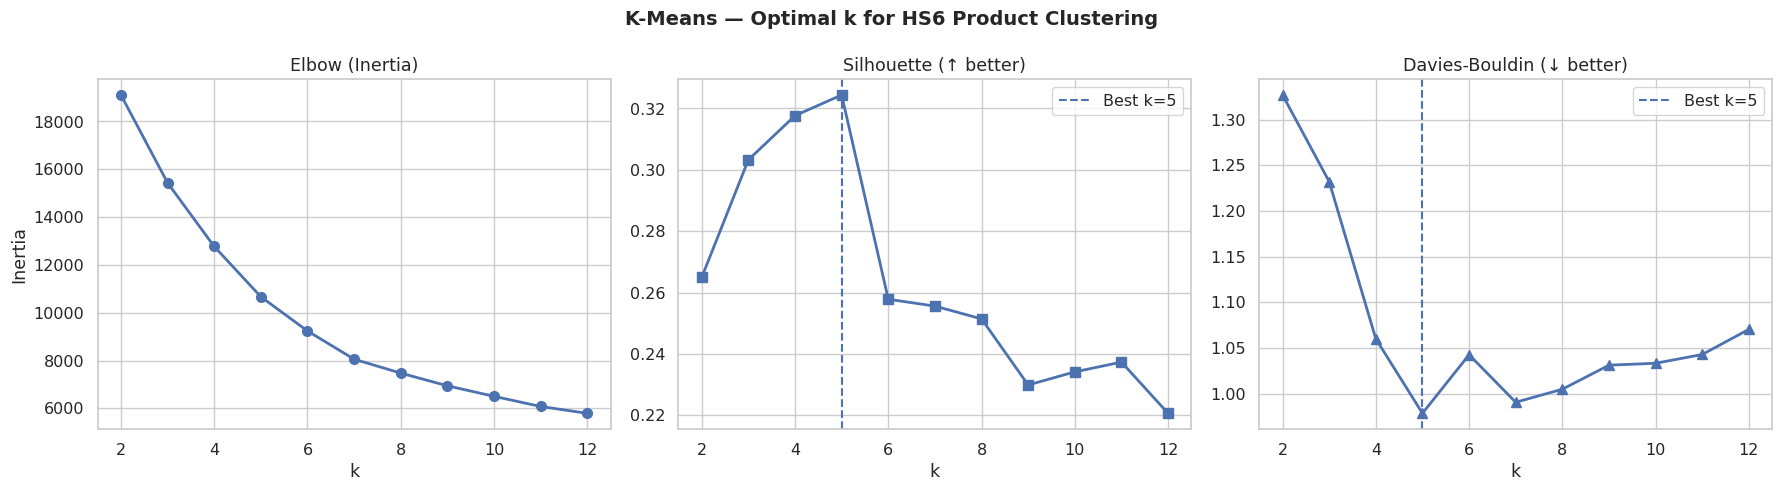


[HS6] ELBOW DETECTION (second derivative)
[HS6] k values : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
[HS6] drops    : [-3675.9, -2662.3, -2102.6, -1431.4, -1180.4, -582.4, -529.6, -441.6, -424.3, -286.5]
[HS6] accel    : [1013.6, 559.7, 671.2, 251.0, 598.0, 52.8, 88.1, 17.3, 137.8]
[HS6] → Algorithm suggests k=3 (inertia=15432.67)
[HS6] NOTE: k=3 may be coarse for segmentation.
[HS6]       Check whether inertia still drops strongly
[HS6]       after k=3.

K_HS6 = 5
  Silhouette      : 0.3244
  Davies-Bouldin  : 0.9783


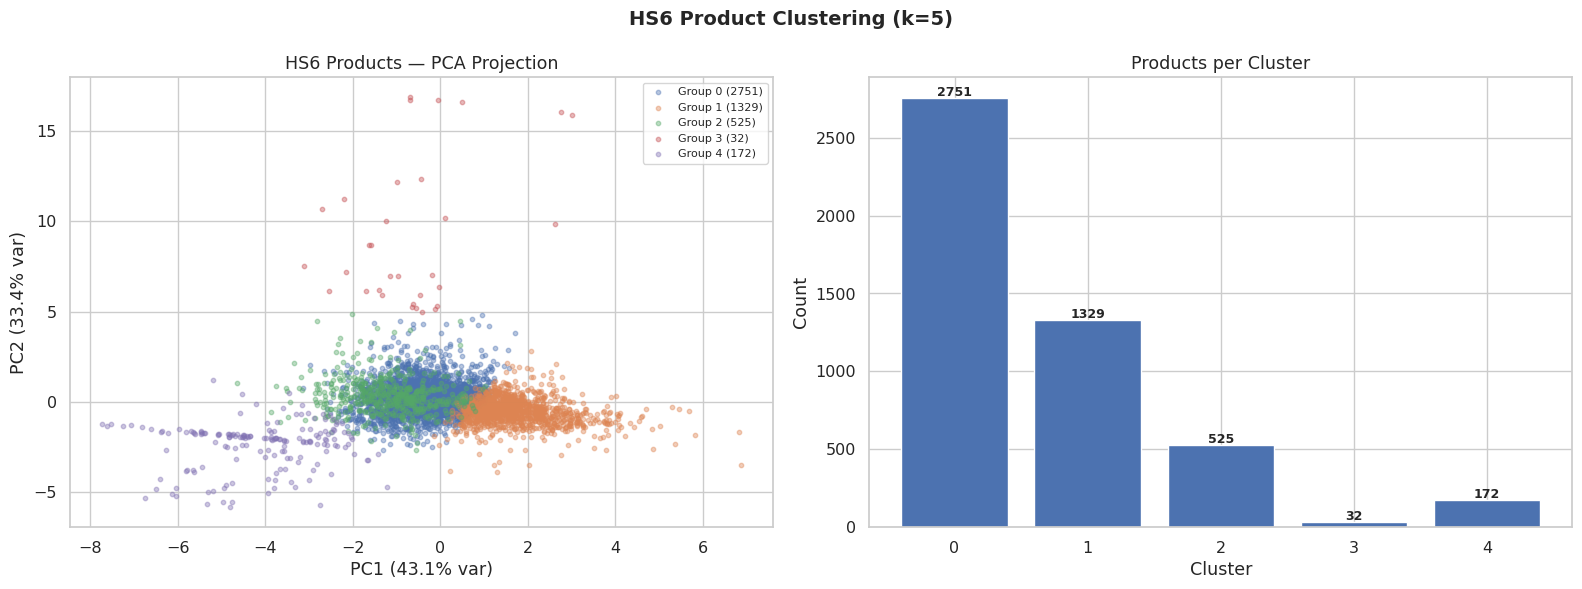

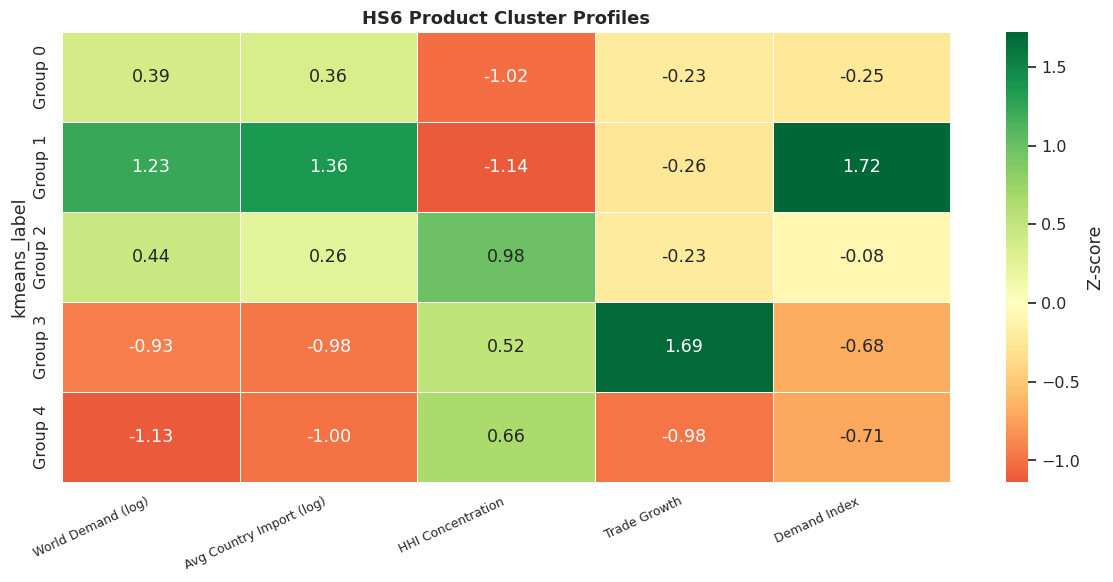


HS6 ARI (K-Means vs HC) : 0.6580
Cluster sizes           : {0: 2751, 1: 1329, 2: 525, 3: 32, 4: 172}

KMeans may still be dominated by outlier products.
Small clusters: {3: 32}

Cluster feature means:
              world_demand_log  global_market_log  hhi_median  export_growth_mean  demand_index_median
kmeans_label                                                                                          
0                       12.821              6.910       0.142               0.798                0.374
1                       15.556              9.283       0.127               0.762                1.859
2                       13.003              6.674       0.408               0.796                0.501
3                        8.558              3.765       0.347               3.076                0.047
4                        7.893              3.706       0.365              -0.096                0.023


33062

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART B.5 — HS6 PRODUCT CLUSTERING (STABLE VERSION)
#
# Goal:
# Cluster 4,949 HS6 products into economically meaningful trade groups
# without degenerate "1 giant cluster + tiny outlier clusters".
#
# Key fixes:
# - Uses smooth log1p transform instead of unstable logit transform
# - Keeps RobustScaler
# - Uses standard KMeans (more stable than MiniBatch here)
# - Keeps memory-safe DuckDB aggregation
#
# 146M rows → 4,949 product profiles entirely inside DuckDB
# ═══════════════════════════════════════════════════════════════════════════════

print('Building HS6 product profiles (deduped sample → ~4,834 rows)...')

hs6_df = con.execute(f"""
SELECT
    CAST(product_code AS VARCHAR) AS product_code,

    -- Global demand size
    approx_quantile(
        ln(1 + GREATEST(world_imports, 0)),
        0.5
    ) AS world_demand_log,

    approx_quantile(
        ln(1 + GREATEST(global_imports, 0)),
        0.5
    ) AS global_market_log,

    -- Market concentration
    approx_quantile(hhi, 0.5) AS hhi_median,

    -- Sparse feature → AVG better than median
    AVG(
        CASE
            WHEN export_growth != 0 THEN export_growth
        END
    ) AS export_growth_mean,

    -- FIXED DEMAND SIGNAL
    -- Smooth spread for tiny values without logit explosion
    approx_quantile(
        ln(1 + global_demand_index * 1000),
        0.5
    ) AS demand_index_median,

    -- Algeria overlay variables
    approx_quantile(market_share,      0.5) AS market_share_median,
    approx_quantile(algeria_exports,   0.5) AS algeria_exports_median,
    approx_quantile(penetration_ratio, 0.5) AS penetration_median,

    SUM(fobvalue) AS fobvalue_total,

    AVG(
        CASE
            WHEN opportunity_level = 'High'
            THEN 1.0 ELSE 0.0
        END
    ) AS pct_high_opp,

    COUNT(DISTINCT partner) AS n_partners

FROM trade_train
WHERE world_imports  > 0
  AND global_imports > 0

GROUP BY product_code
ORDER BY product_code
""").fetchdf()

# ─────────────────────────────────────────────────────────────────────────────
# CLEANUP
# ─────────────────────────────────────────────────────────────────────────────

hs6_df['export_growth_mean'] = (
    hs6_df['export_growth_mean']
    .fillna(0)
)

print(
    f'  HS6 profiles : {len(hs6_df)} products | '
    f'{hs6_df.memory_usage(deep=True).sum()/1e6:.1f} MB'
)

gc.collect()

# ─────────────────────────────────────────────────────────────────────────────
# FEATURE SET
# ─────────────────────────────────────────────────────────────────────────────

HS6_FEAT = [
    'world_demand_log',
    'global_market_log',
    'hhi_median',
    'export_growth_mean',
    'demand_index_median',
]

HS6_FEAT_LABELS = [
    'World Demand (log)',
    'Avg Country Import (log)',
    'HHI Concentration',
    'Trade Growth',
    'Demand Index'
]

# ─────────────────────────────────────────────────────────────────────────────
# MISSING / INF HANDLING
# ─────────────────────────────────────────────────────────────────────────────

hs6_df = (
    hs6_df
    .dropna(subset=HS6_FEAT, how='all')
    .reset_index(drop=True)
)

hs6_df[HS6_FEAT] = (
    hs6_df[HS6_FEAT]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(hs6_df[HS6_FEAT].median())
)

# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTICS
# ─────────────────────────────────────────────────────────────────────────────

print('\n[DIAGNOSTIC] HS6 feature IQR + CV check:')

print(
    f"{'Feature':<26} "
    f"{'Mean':>8} "
    f"{'Std':>8} "
    f"{'IQR':>10} "
    f"{'CV%':>7}  Decision"
)

print('-' * 76)

for feat in HS6_FEAT:

    m   = hs6_df[feat].mean()
    s   = hs6_df[feat].std()

    iqr = (
        hs6_df[feat].quantile(0.75)
        - hs6_df[feat].quantile(0.25)
    )

    cv = abs(s / m) * 100 if m != 0 else 0

    flag = (
        'OK'
        if (iqr > 1e-4 and cv > 2.0)
        else 'DEGENERATE'
    )

    print(
        f'  {feat:<24} '
        f'{m:>8.4f} '
        f'{s:>8.4f} '
        f'{iqr:>10.5f} '
        f'{cv:>6.1f}%  '
        f'{flag}'
    )

print(
    f'\nHS6 profile matrix: '
    f'{hs6_df.shape[0]} products × {len(HS6_FEAT)} features'
)

# ─────────────────────────────────────────────────────────────────────────────
# SCALE
# ─────────────────────────────────────────────────────────────────────────────

scaler_h = RobustScaler()

X_h = scaler_h.fit_transform(
    hs6_df[HS6_FEAT]
)

X_h = np.nan_to_num(
    X_h,
    nan=0.0,
    posinf=5.0,
    neginf=-5.0
)

print(f'Scaled: {X_h.shape} | NaN: {np.isnan(X_h).sum()}')

gc.collect()

# ─────────────────────────────────────────────────────────────────────────────
# K SELECTION
# ─────────────────────────────────────────────────────────────────────────────

K_range_h = range(2, 13)

inertias_h = []
sil_h      = []
db_h       = []

print('\nRunning k selection (k=2..12)...')

for k in K_range_h:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labs = km.fit_predict(X_h)

    inertias_h.append(km.inertia_)

    sil_h.append(
        silhouette_score(
            X_h,
            labs,
            sample_size=2000,
            random_state=42
        )
    )

    db_h.append(
        davies_bouldin_score(X_h, labs)
    )

    print(
        f'  k={k} | '
        f'inertia={km.inertia_:.1f} | '
        f'sil={sil_h[-1]:.4f}',
        end='\r'
    )

print()

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE K SELECTION
# ─────────────────────────────────────────────────────────────────────────────

best_sil_h = list(K_range_h)[sil_h.index(max(sil_h))]
best_db_h  = list(K_range_h)[db_h.index(min(db_h))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle(
    'K-Means — Optimal k for HS6 Product Clustering',
    fontsize=14,
    fontweight='bold'
)

# Elbow
axes[0].plot(
    K_range_h,
    inertias_h,
    'o-',
    lw=2,
    ms=7
)

axes[0].set_title('Elbow (Inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

# Silhouette
axes[1].plot(
    K_range_h,
    sil_h,
    's-',
    lw=2,
    ms=7
)

axes[1].axvline(
    best_sil_h,
    ls='--',
    lw=1.5,
    label=f'Best k={best_sil_h}'
)

axes[1].set_title('Silhouette (↑ better)')
axes[1].set_xlabel('k')
axes[1].legend()

# Davies-Bouldin
axes[2].plot(
    K_range_h,
    db_h,
    '^-',
    lw=2,
    ms=7
)

axes[2].axvline(
    best_db_h,
    ls='--',
    lw=1.5,
    label=f'Best k={best_db_h}'
)

axes[2].set_title('Davies-Bouldin (↓ better)')
axes[2].set_xlabel('k')
axes[2].legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'fig11_hs6_k_selection.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# ELBOW SELECTION
# ─────────────────────────────────────────────────────────────────────────────

elbow_k_h, _ = _identify_elbow(
    inertias_h,
    K_range_h,
    label='HS6'
)

K_HS6 = 5 #elbow_k_h

print(f'\nK_HS6 = {K_HS6}')

print(
    f'  Silhouette      : '
    f'{sil_h[list(K_range_h).index(K_HS6)]:.4f}'
)

print(
    f'  Davies-Bouldin  : '
    f'{db_h[list(K_range_h).index(K_HS6)]:.4f}'
)

# ─────────────────────────────────────────────────────────────────────────────
# FINAL KMEANS
# ─────────────────────────────────────────────────────────────────────────────

km_h = KMeans(
    n_clusters=K_HS6,
    random_state=42,
    n_init=20
)

hs6_df['kmeans_label'] = km_h.fit_predict(X_h)

# ─────────────────────────────────────────────────────────────────────────────
# HIERARCHICAL VALIDATION
# ─────────────────────────────────────────────────────────────────────────────

hc_h = AgglomerativeClustering(
    n_clusters=K_HS6,
    linkage='ward'
)

hs6_df['hc_label'] = hc_h.fit_predict(X_h)

# ─────────────────────────────────────────────────────────────────────────────
# PCA PROJECTION
# ─────────────────────────────────────────────────────────────────────────────

pca_h = PCA(
    n_components=2,
    random_state=42
)

coords_h = pca_h.fit_transform(X_h)

hs6_df['PC1'] = coords_h[:, 0]
hs6_df['PC2'] = coords_h[:, 1]

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE CLUSTERS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    f'HS6 Product Clustering (k={K_HS6})',
    fontsize=14,
    fontweight='bold'
)

# PCA scatter
ax = axes[0]

for k in range(K_HS6):

    mask = hs6_df['kmeans_label'] == k

    ax.scatter(
        hs6_df.loc[mask, 'PC1'],
        hs6_df.loc[mask, 'PC2'],
        s=10,
        alpha=0.4,
        label=f'Group {k} ({mask.sum()})'
    )

ax.set_xlabel(
    f'PC1 ({pca_h.explained_variance_ratio_[0]*100:.1f}% var)'
)

ax.set_ylabel(
    f'PC2 ({pca_h.explained_variance_ratio_[1]*100:.1f}% var)'
)

ax.set_title('HS6 Products — PCA Projection')

ax.legend(fontsize=8)

# Cluster sizes
sizes = hs6_df.groupby('kmeans_label').size()

axes[1].bar(
    range(K_HS6),
    sizes.values
)

for i, v in enumerate(sizes.values):

    axes[1].text(
        i,
        v + 15,
        str(v),
        ha='center',
        fontweight='bold',
        fontsize=9
    )

axes[1].set_title('Products per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'fig12_hs6_clustering.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# HEATMAP
# ─────────────────────────────────────────────────────────────────────────────

profile_h = (
    hs6_df
    .groupby('kmeans_label')[HS6_FEAT]
    .mean()
)

profile_h_norm = (
    (profile_h - profile_h.mean())
    / (profile_h.std() + 1e-9)
)

fig, ax = plt.subplots(
    figsize=(12, max(4, K_HS6 + 1))
)

sns.heatmap(
    profile_h_norm,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    center=0,
    xticklabels=HS6_FEAT_LABELS,
    yticklabels=[f'Group {k}' for k in profile_h_norm.index],
    cbar_kws={'label': 'Z-score'},
    ax=ax
)

ax.set_title(
    'HS6 Product Cluster Profiles',
    fontsize=13,
    fontweight='bold'
)

ax.set_xticklabels(
    HS6_FEAT_LABELS,
    rotation=25,
    ha='right',
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'fig13_hs6_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# VALIDATION
# ─────────────────────────────────────────────────────────────────────────────

ari_h = adjusted_rand_score(
    hs6_df['kmeans_label'],
    hs6_df['hc_label']
)

cluster_sizes = (
    hs6_df['kmeans_label']
    .value_counts()
    .sort_index()
)

print(f'\nHS6 ARI (K-Means vs HC) : {ari_h:.4f}')
print(f'Cluster sizes           : {cluster_sizes.to_dict()}')

# Warn if tiny clusters remain
small_clusters = cluster_sizes[cluster_sizes < 100]

if len(small_clusters) > 0:

    print('\nWARNING: extremely small clusters detected.')
    print('KMeans may still be dominated by outlier products.')
    print(f'Small clusters: {small_clusters.to_dict()}')

print('\nCluster feature means:')

print(
    profile_h[HS6_FEAT]
    .round(3)
    .to_string()
)

gc.collect()

In [ ]:
print("HS6 product clusters:")
print(hs6_df['kmeans_label'].value_counts().sort_index())
print("\nHS6 features mean by cluster:")
print(hs6_df.groupby('kmeans_label')[PRODUCT_FEAT].mean().round(3))

In [ ]:
print(hs6_df.columns.tolist())

In [ ]:
PRODUCT_FEAT = ['world_demand_log', 'global_market_log', 'hhi_median', 
                'export_growth_mean', 'demand_index_median', 'n_partners']

print(hs6_df.groupby('kmeans_label')[PRODUCT_FEAT].mean().round(3))

---
# PART C — Algeria Overlay
## 11. Where Does Algeria Fit in the Global Clusters?

Now we bring Algeria back in — not to drive the clustering, but to **position Algeria within the global segments**.  
This answers: which country clusters are the best targets for Algeria? Which sector clusters match Algeria's capabilities?

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART C — Algeria Overlay
# 11. Where Does Algeria Fit in the Global Clusters?
# ═══════════════════════════════════════════════════════════════════════════════

def minmax_norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

# ── Opportunity score ─────────────────────────────────────────────────────────
# Formula: high global demand × low Algeria presence × wealthy partner
#
# country_df columns confirmed from aggregation cell:
#   demand proxy  → market_size_log       (how much this country imports globally)
#   share         → market_share_robust   (Algeria's share of world exports here)
#   penetration   → penetration_robust    (Algeria's share of this country's imports)
#   wealth        → wealth_log            (log GDP)
#   fobvalue      → fobvalue_total        (total Algeria exports to this country)
#
# NOTE: demand_index was only computed for sectors, not countries in this version.
# market_size_log is the correct country-level demand proxy — it captures
# how large this country's import appetite is across all products globally.

demand_norm  = minmax_norm(country_df['market_size_log'].fillna(0))
share_norm   = minmax_norm(country_df['market_share_robust'].fillna(0))
penetr_norm  = minmax_norm(country_df['penetration_robust'].fillna(0))
wealth_norm  = minmax_norm(country_df['wealth_log'].fillna(0))

# Weight: market size 40%, untapped share 30%, untapped penetration 20%, wealth 10%
country_df['opportunity_score'] = (
    0.40 * demand_norm        +   # large importer           → attractive
    0.30 * (1 - share_norm)   +   # low Algeria share        → untapped
    0.20 * (1 - penetr_norm)  +   # low Algeria penetration  → room to grow
    0.10 * wealth_norm             # wealthy partner          → can pay
)
country_df['opportunity_score'] = minmax_norm(country_df['opportunity_score'])

# Label by tertile
country_df['opp_level'] = pd.qcut(
    country_df['opportunity_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# ── Cross-tab: cluster vs opportunity level ───────────────────────────────────
crosstab = pd.crosstab(
    country_df['kmeans_label'],
    country_df['opp_level'],
    normalize='index'
).round(3) * 100

print('=== Country Cluster vs Opportunity Level (% within cluster) ===')
print(crosstab.to_string())
print('\n→ Clusters with highest HIGH% = most untapped opportunity for Algeria')

# ── Cluster summary ───────────────────────────────────────────────────────────
cluster_summary = country_df.groupby('kmeans_label').agg(
    n_countries       = ('partner',            'count'),
    avg_market_share  = ('market_share_robust', 'mean'),
    avg_penetration   = ('penetration_robust',  'mean'),
    total_algeria_exp = ('fobvalue_total',      'sum'),
    avg_opportunity   = ('opportunity_score',   'mean'),
).round(4)

cluster_summary = cluster_summary.sort_values('avg_opportunity', ascending=False)

print('\n=== Algeria Cluster Strategy Summary (sorted by opportunity) ===')
print(cluster_summary.to_string())
print('\nColumns:')
print('  avg_market_share  : Algeria export presence (lower = more untapped)')
print('  avg_penetration   : Algeria penetration level (lower = more room to grow)')
print('  total_algeria_exp : Current total exports to this cluster (USD)')
print('  avg_opportunity   : Export attractiveness score (higher = more untapped)')

=== Country Cluster vs Opportunity Level (% within cluster) ===
opp_level      Low  Medium  High
kmeans_label                    
0             10.7    42.9  46.4
1             83.7    16.3   0.0
2             40.0    20.0  40.0
3             35.6    56.2   8.2
4              0.0    16.4  83.6

→ Clusters with highest HIGH% = most untapped opportunity for Algeria

=== Algeria Cluster Strategy Summary (sorted by opportunity) ===
              n_countries  avg_market_share  avg_penetration  total_algeria_exp  avg_opportunity
kmeans_label                                                                                    
4                      61               0.0           0.0001       5.949302e+09           0.8238
0                      28               0.0           0.0005       2.224500e+09           0.7448
2                       5               0.0           0.0081       3.865021e+08           0.7199
3                      73               0.0           0.1079       3.244107e+09    

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART C.5 — WHERE ALGERIA CAN REALISTICALLY EXPAND NEXT
# PRODUCT SPACE + CURRENT + NEAR-FUTURE CAPABILITY MODEL
# ═══════════════════════════════════════════════════════════════════════════════

print('Computing realistic expansion opportunities...')

import numpy as np
import pandas as pd

# ──────────────────────────────────────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────────────────────────────────────
def minmax_norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

# ──────────────────────────────────────────────────────────────────────────────
# STRUCTURE
# ──────────────────────────────────────────────────────────────────────────────
hs6_df['chapter'] = hs6_df['product_code'].astype(str).str[:2]

# ──────────────────────────────────────────────────────────────────────────────
# 1) GLOBAL OPPORTUNITY (external demand signal)
# ──────────────────────────────────────────────────────────────────────────────
demand = minmax_norm(hs6_df['world_demand_log'])
share = minmax_norm(hs6_df['market_share_median'].clip(lower=0))
growth = minmax_norm(hs6_df['export_growth_mean'])
opp = minmax_norm(hs6_df['pct_high_opp'])

hs6_df['global_opportunity'] = minmax_norm(
    0.40 * demand +
    0.25 * (1 - share) +
    0.20 * opp +
    0.15 * growth
)

# ──────────────────────────────────────────────────────────────────────────────
# 2) CURRENT CAPABILITY (what Algeria already exports)
# ──────────────────────────────────────────────────────────────────────────────
hs6_df['current_capability'] = minmax_norm(
    np.log1p(hs6_df['fobvalue_total'].clip(lower=0))
)

# ──────────────────────────────────────────────────────────────────────────────
# 3) NEAR-FUTURE CAPABILITY (KEY UPGRADE)
#    - sector adjacency
#    - complexity penalty
# ──────────────────────────────────────────────────────────────────────────────

# Sector adjacency (industrial proximity)
adjacent_chapters = {
    '01','02','03','07','08','09','10','11','12',
    '20','22',
    '25','26','28','29','31','32',
    '39',
    '72','73','74',
    '84','85',
    '87'
}

hs6_df['is_adjacent'] = hs6_df['chapter'].isin(adjacent_chapters)

# Complexity levels (higher = harder to reach)
complexity_penalty = {
    '01': 0.95, '02': 0.95, '03': 0.95,
    '07': 0.90, '10': 0.90,

    '20': 0.85, '22': 0.80,

    '25': 0.75, '26': 0.75,
    '28': 0.75, '29': 0.70, '31': 0.70, '32': 0.70,

    '39': 0.80,

    '72': 0.75, '73': 0.70, '74': 0.70,

    '84': 0.55,
    '85': 0.40,

    '87': 0.60,

    '88': 0.20,  # aerospace (very hard)
    '89': 0.25,
    '90': 0.30
}

hs6_df['complexity_factor'] = hs6_df['chapter'].map(complexity_penalty).fillna(0.5)

# near-future capability = adjacency × inverse complexity
hs6_df['future_capability'] = (
    hs6_df['is_adjacent'].astype(int) * hs6_df['complexity_factor']
)

# normalize for stability
hs6_df['future_capability'] = minmax_norm(hs6_df['future_capability'])

# ──────────────────────────────────────────────────────────────────────────────
# 4) FINAL EXPANSION SCORE (CORE MODEL)
# ──────────────────────────────────────────────────────────────────────────────
hs6_df['expansion_score'] = minmax_norm(
    hs6_df['global_opportunity'] *
    (0.55 * hs6_df['current_capability'] +
     0.45 * hs6_df['future_capability'])
)

# ──────────────────────────────────────────────────────────────────────────────
# 5) HARD FILTERS
# ──────────────────────────────────────────────────────────────────────────────
demand_cut = hs6_df['world_demand_log'].quantile(0.25)

candidates = hs6_df[
    (hs6_df['n_partners'] >= 20) &
    (hs6_df['world_demand_log'] >= demand_cut) &
    (hs6_df['chapter'] != '27') &          # remove hydrocarbons
    (hs6_df['is_adjacent'])               # enforce realistic expansion space
].copy()

candidates = candidates.sort_values(
    'expansion_score',
    ascending=False
)

print(f'  Total HS6 products : {len(hs6_df)}')
print(f'  Realistic expansion candidates : {len(candidates)}')

top30 = candidates.head(30).copy()

# ──────────────────────────────────────────────────────────────────────────────
# DESCRIPTION JOIN
# ──────────────────────────────────────────────────────────────────────────────
top_codes = top30['product_code'].astype(str).tolist()
codes_sql = ', '.join(f"'{c}'" for c in top_codes)

desc_df = con.execute(f"""
SELECT
    CAST(product_code AS VARCHAR) AS product_code,
    ANY_VALUE(product_description) AS product_description
FROM trade
WHERE CAST(product_code AS VARCHAR) IN ({codes_sql})
GROUP BY product_code
""").fetchdf()

top30 = top30.merge(desc_df, on='product_code', how='left')

# ──────────────────────────────────────────────────────────────────────────────
# OUTPUT
# ──────────────────────────────────────────────────────────────────────────────
print()
print('=' * 110)
print('WHERE ALGERIA CAN REALISTICALLY EXPAND NEXT (PRODUCT SPACE MODEL)')
print('=' * 110)

print(f"{'#':<3} {'HS6':<8} {'Ch':<3} {'Description':<45} {'Score':>8}")

print('-' * 110)

for i, (_, r) in enumerate(top30.iterrows(), 1):

    desc = str(r.get('product_description', 'N/A'))[:43]

    print(
        f"{i:<3} {r['product_code']:<8} {r['chapter']:<3} "
        f"{desc:<45} {r['expansion_score']:.4f}"
    )

Computing realistic expansion opportunities...
  Total HS6 products : 4809
  Realistic expansion candidates : 1880

WHERE ALGERIA CAN REALISTICALLY EXPAND NEXT (PRODUCT SPACE MODEL)
#   HS6      Ch  Description                                      Score
--------------------------------------------------------------------------------------------------------------
1   870323   87  Vehicles: spark-ignition internal combustio   1.0000
2   392690   39  Plastics: other articles n.e.s. in chapter    0.9330
3   100190   10  Cereals: meslin and wheat other than durum    0.8885
4   732690   73  Iron or steel: articles n.e.s. in heading n   0.8562
5   870324   87  Vehicles: spark-ignition internal combustio   0.8466
6   852520   85  Transmission apparatus: for radio-telephony   0.8384
7   260111   26  Iron ores and concentrates: non-agglomerate   0.8311
8   870899   87  Vehicles: parts and accessories, n.e.s. in    0.8261
9   847330   84  Machines: parts and accessories of automati   0.8108
10  7

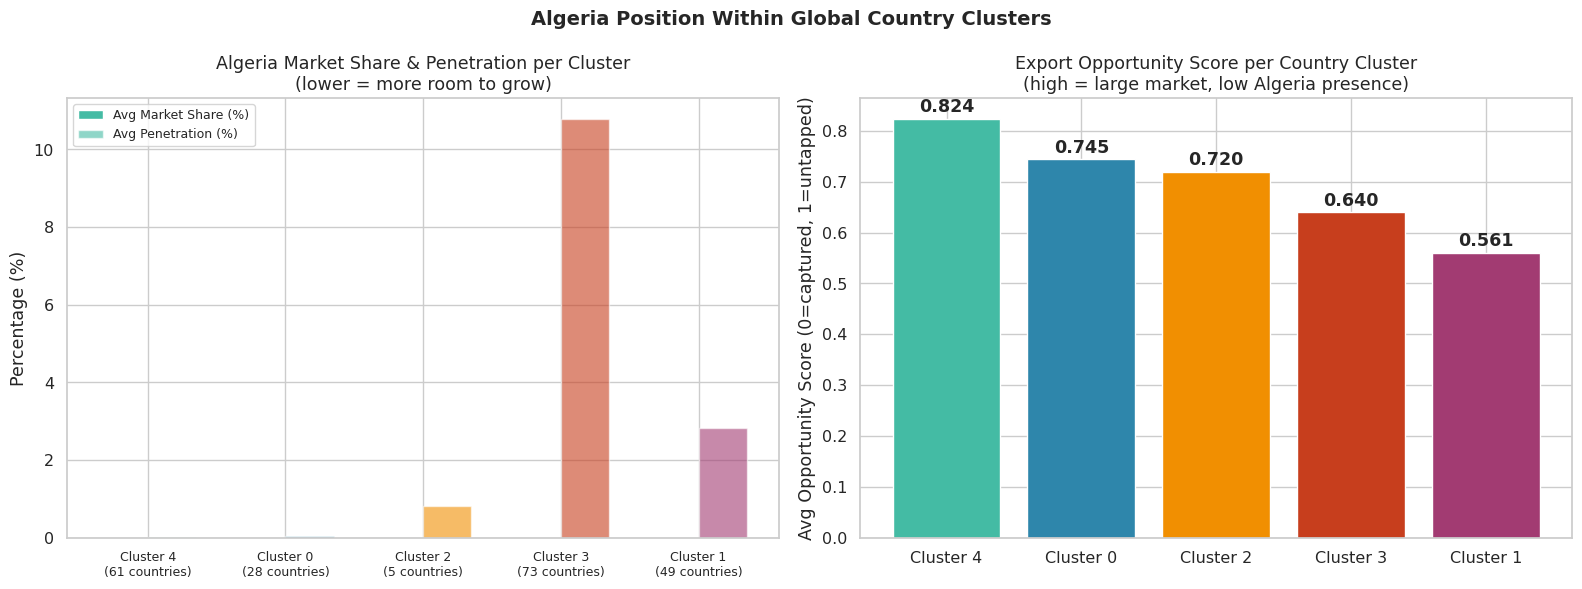


=== Algeria Presence per Sector Cluster ===
              n_chapters  algeria_exports  market_share  pct_high_opp
kmeans_label                                                         
0                     23        11.323600        0.0000        0.2956
1                      9        85.522697        0.0003        0.2865
2                     64         1.386100        0.0000        0.2679

→ High pct_high_opp + low market_share = biggest product opportunities


In [31]:
# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Algeria Position Within Global Country Clusters',
             fontsize=14, fontweight='bold')

# cluster_summary is sorted by avg_opportunity — reset for positional indexing
cs = cluster_summary.reset_index()

# Left: market share and penetration per cluster (lower = more room to grow)
ax = axes[0]
x = np.arange(K_BEST)
w = 0.35
ax.bar(x - w/2, cs['avg_market_share'] * 100, w,
       label='Avg Market Share (%)',
       color=[PALETTE[int(cs.loc[i, 'kmeans_label'])] for i in range(K_BEST)])
ax.bar(x + w/2, cs['avg_penetration'] * 100, w,
       label='Avg Penetration (%)',
       color=[PALETTE[int(cs.loc[i, 'kmeans_label'])] for i in range(K_BEST)],
       alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(
    [f'Cluster {int(cs.loc[i, "kmeans_label"])}\n({int(cs.loc[i, "n_countries"])} countries)'
     for i in range(K_BEST)],
    fontsize=9
)
ax.set_ylabel('Percentage (%)')
ax.set_title('Algeria Market Share & Penetration per Cluster\n(lower = more room to grow)')
ax.legend(fontsize=9)

# Right: opportunity score per cluster (sorted high to low = left to right)
ax = axes[1]
bars = ax.bar(
    range(K_BEST),
    cs['avg_opportunity'],
    color=[PALETTE[int(cs.loc[i, 'kmeans_label'])] for i in range(K_BEST)],
    edgecolor='white'
)
for bar, v in zip(bars, cs['avg_opportunity']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_xticks(range(K_BEST))
ax.set_xticklabels(
    [f'Cluster {int(cs.loc[i, "kmeans_label"])}' for i in range(K_BEST)]
)
ax.set_ylabel('Avg Opportunity Score (0=captured, 1=untapped)')
ax.set_title('Export Opportunity Score per Country Cluster\n(high = large market, low Algeria presence)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_algeria_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sector overlay ────────────────────────────────────────────────────────────
# sector_df confirmed columns: market_share_robust, algeria_exports_median, pct_high_opp
sector_summary = sector_df.groupby('kmeans_label').agg(
    n_chapters      = ('chapter',               'count'),
    algeria_exports = ('algeria_exports_median', 'mean'),
    market_share    = ('market_share_robust',    'mean'),
    pct_high_opp    = ('pct_high_opp',           'mean'),
).round(4)

print('\n=== Algeria Presence per Sector Cluster ===')
print(sector_summary.to_string())
print('\n→ High pct_high_opp + low market_share = biggest product opportunities')

---
## 12.5 Cluster Generalisation Validation (train-fit → val-evaluate)

Metrics below use cluster models **fit on training profiles only**, then evaluated on:
1. **Row holdout** — profiles rebuilt from `trade_val`
2. **Temporal holdout** — profiles from `trade_val_temporal` (2020–2024) vs train temporal (2010–2019)
3. **K-fold CV** — on training country profiles (entity-level folds)
4. **Bootstrap 95% CI** — silhouette on resampled train country profiles

Silhouette and Davies–Bouldin on validation use the **training scaler** and **training cluster centroids** (nearest-centroid assignment).


In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDATION: generalisation of cluster structure (after train-only clustering)
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import KFold

def _assign_and_score(X_train_fit, labels_train, X_val, feat_cols, k):
    """Assign validation points to nearest train centroids; return silhouette & DB."""
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_tmp.fit(X_train_fit)
    val_labels = km_tmp.predict(X_val)
    if len(np.unique(val_labels)) < 2:
        return np.nan, np.nan
    return silhouette_score(X_val, val_labels), davies_bouldin_score(X_val, val_labels)


def build_country_profiles_sql(source_view):
    return con.execute(f"""
    SELECT
        partner,
        COUNT(DISTINCT product_code) AS n_products,
        approx_quantile(ln(1 + GREATEST(global_imports, 0)), 0.5) AS market_size_log,
        approx_quantile(ln(1 + GREATEST(world_imports, 0)), 0.5) AS world_demand_log,
        approx_quantile(global_demand_index, 0.5) AS demand_index_robust,
        approx_quantile(hhi, 0.5) AS hhi_robust,
        AVG(CASE WHEN export_growth != 0 THEN export_growth END) AS demand_growth_robust,
        approx_quantile(ln(1 + GREATEST(gdp, 0)), 0.5) AS wealth_log,
        approx_quantile(ln(1 + GREATEST(population, 0)), 0.5) AS pop_log,
        approx_quantile(trade_percent_gdp, 0.5) AS trade_openness_robust,
        approx_quantile(gdp_growth, 0.5) AS gdp_growth_robust
    FROM {source_view}
    WHERE global_imports > 0 AND world_imports > 0
    GROUP BY partner
    """).fetchdf()


def prep_country_df(raw_df, feat_list):
    df = raw_df.dropna(subset=feat_list, how='all').reset_index(drop=True)
    df[feat_list] = (
        df[feat_list].replace([np.inf, -np.inf], np.nan).fillna(df[feat_list].median())
    )
    return df


# ── 1. Row holdout: val profiles + train scaler/centroids ─────────────────────
country_val_df = prep_country_df(build_country_profiles_sql('trade_val'), COUNTRY_FEAT)
X_val_c = scaler_c.transform(country_val_df[COUNTRY_FEAT])
val_labels_c = km_c.predict(X_val_c)
sil_val_c = silhouette_score(X_val_c, val_labels_c)
db_val_c = davies_bouldin_score(X_val_c, val_labels_c)

# ── 2. Temporal holdout ───────────────────────────────────────────────────────
country_val_temp_df = prep_country_df(
    build_country_profiles_sql('trade_val_temporal'), COUNTRY_FEAT
)
common_partners = sorted(
    set(country_df['partner']) & set(country_val_temp_df['partner'])
)
if len(common_partners) >= K_BEST + 1:
    tr_sub = country_df[country_df['partner'].isin(common_partners)].set_index('partner')
    va_sub = country_val_temp_df[country_val_temp_df['partner'].isin(common_partners)].set_index('partner')
    tr_sub = tr_sub.loc[common_partners]
    va_sub = va_sub.loc[common_partners]
    X_tr_t = scaler_c.transform(tr_sub[COUNTRY_FEAT])
    X_va_t = scaler_c.transform(va_sub[COUNTRY_FEAT])
    lbl_tr = km_c.predict(X_tr_t)
    lbl_va = km_c.predict(X_va_t)
    ari_temporal_c = adjusted_rand_score(lbl_tr, lbl_va)
    sil_temporal_c = silhouette_score(X_va_t, lbl_va)
    db_temporal_c = davies_bouldin_score(X_va_t, lbl_va)
else:
    ari_temporal_c = sil_temporal_c = db_temporal_c = np.nan

# ── 3. K-fold CV on train country profiles ────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sil_folds, db_folds = [], []
X_c_train = scaler_c.transform(country_df[COUNTRY_FEAT])
for tr_idx, te_idx in kf.split(X_c_train):
    X_fold_tr, X_fold_te = X_c_train[tr_idx], X_c_train[te_idx]
    km_fold = KMeans(n_clusters=K_BEST, random_state=RANDOM_STATE, n_init=10)
    km_fold.fit(X_fold_tr)
    fold_lbl = km_fold.predict(X_fold_te)
    if len(np.unique(fold_lbl)) >= 2:
        sil_folds.append(silhouette_score(X_fold_te, fold_lbl))
        db_folds.append(davies_bouldin_score(X_fold_te, fold_lbl))
sil_kfold_mean = float(np.mean(sil_folds)) if sil_folds else np.nan
db_kfold_mean = float(np.mean(db_folds)) if db_folds else np.nan

# ── 4. Bootstrap 95% CI (train country profiles) ─────────────────────────────
N_BOOT = 200
sil_boot = []
rng = np.random.default_rng(RANDOM_STATE)
n_c = len(country_df)
for _ in range(N_BOOT):
    idx = rng.integers(0, n_c, size=n_c)
    X_b = X_c_train[idx]
    km_b = KMeans(n_clusters=K_BEST, random_state=RANDOM_STATE, n_init=10)
    lbl_b = km_b.fit_predict(X_b)
    if len(np.unique(lbl_b)) >= 2:
        sil_boot.append(silhouette_score(X_b, lbl_b))
sil_boot_ci = (np.percentile(sil_boot, 2.5), np.percentile(sil_boot, 97.5)) if sil_boot else (np.nan, np.nan)

validation_rows = [
    {'strategy': 'row_holdout_val', 'level': 'Countries', 'k': K_BEST,
     'silhouette': round(sil_val_c, 4), 'davies_bouldin': round(db_val_c, 4)},
    {'strategy': 'temporal_val_2020_2024', 'level': 'Countries', 'k': K_BEST,
     'silhouette': round(sil_temporal_c, 4), 'davies_bouldin': round(db_temporal_c, 4),
     'ari_vs_train': round(ari_temporal_c, 4)},
    {'strategy': 'kfold_5_train_profiles', 'level': 'Countries', 'k': K_BEST,
     'silhouette': round(sil_kfold_mean, 4), 'davies_bouldin': round(db_kfold_mean, 4)},
    {'strategy': 'bootstrap_200_train', 'level': 'Countries', 'k': K_BEST,
     'silhouette_lo': round(sil_boot_ci[0], 4), 'silhouette_hi': round(sil_boot_ci[1], 4)},
]

# Sectors + HS6 row holdout (when those models exist)
if 'km_s' in dir() and 'scaler_s' in dir() and 'SECTOR_FEAT' in dir():
    sector_val_raw = con.execute("""
    SELECT hs2 AS chapter,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY LN(GREATEST(world_imports, 0.001))) AS world_demand_log,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY LN(GREATEST(global_imports, 0.001))) AS global_market_log,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY global_demand_index) AS demand_index_robust,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hhi) AS hhi_robust,
        AVG(CASE WHEN export_growth != 0 THEN export_growth END) AS export_growth_robust
    FROM trade_val WHERE world_imports > 0 AND global_imports > 0 GROUP BY chapter
    """).fetchdf()
    sector_val_df = sector_val_raw.dropna(subset=SECTOR_FEAT, how='all').reset_index(drop=True)
    sector_val_df[SECTOR_FEAT] = sector_val_df[SECTOR_FEAT].replace([np.inf, -np.inf], np.nan).fillna(sector_val_df[SECTOR_FEAT].median())
    X_val_s = scaler_s.transform(sector_val_df[SECTOR_FEAT])
    lbl_val_s = km_s.predict(X_val_s)
    validation_rows.append({'strategy': 'row_holdout_val', 'level': 'Sectors', 'k': K_SECTOR,
        'silhouette': round(silhouette_score(X_val_s, lbl_val_s), 4),
        'davies_bouldin': round(davies_bouldin_score(X_val_s, lbl_val_s), 4)})

if 'km_h' in dir() and 'scaler_h' in dir() and 'HS6_FEAT' in dir():
    hs6_val_raw = con.execute("""
    SELECT product_code,
        approx_quantile(ln(1 + GREATEST(world_imports, 0)), 0.5) AS world_demand_log,
        approx_quantile(ln(1 + global_demand_index * 1000), 0.5) AS demand_index_median,
        approx_quantile(hhi, 0.5) AS hhi_median,
        AVG(CASE WHEN export_growth != 0 THEN export_growth END) AS export_growth_mean,
        approx_quantile(ln(1 + GREATEST(global_imports, 0)), 0.5) AS global_market_log
    FROM trade_val WHERE world_imports > 0 AND global_imports > 0 GROUP BY product_code
    """).fetchdf()
    hs6_val_df = hs6_val_raw.dropna(subset=HS6_FEAT, how='all').reset_index(drop=True)
    hs6_val_df[HS6_FEAT] = hs6_val_df[HS6_FEAT].replace([np.inf, -np.inf], np.nan).fillna(hs6_val_df[HS6_FEAT].median())
    X_val_h = scaler_h.transform(hs6_val_df[HS6_FEAT])
    lbl_val_h = km_h.predict(X_val_h)
    validation_rows.append({'strategy': 'row_holdout_val', 'level': 'HS6', 'k': K_HS6,
        'silhouette': round(silhouette_score(X_val_h, lbl_val_h), 4),
        'davies_bouldin': round(davies_bouldin_score(X_val_h, lbl_val_h), 4)})

val_df = pd.DataFrame(validation_rows)
val_df.to_csv(OUT_DIR / 'clustering_validation.csv', index=False)

print('=' * 72)
print('CLUSTER GENERALISATION VALIDATION (train-fit → val / CV / bootstrap)')
print('=' * 72)
print(val_df.to_string(index=False))
print()
print(f'Row holdout val — Countries: Silhouette={sil_val_c:.4f}, DB={db_val_c:.4f}')
print(f'Temporal val (2020-2024) — Silhouette={sil_temporal_c:.4f}, ARI vs train={ari_temporal_c:.4f}')
print(f'5-fold CV (train profiles) — Silhouette mean={sil_kfold_mean:.4f}')
print(f'Bootstrap 95% CI (train silhouette): [{sil_boot_ci[0]:.4f}, {sil_boot_ci[1]:.4f}]')
print('=' * 72)


CLUSTER GENERALISATION VALIDATION (train-fit → val / CV / bootstrap)
              strategy     level  k  silhouette  davies_bouldin  ari_vs_train  silhouette_lo  silhouette_hi
       row_holdout_val Countries  5      0.2741          1.1192           NaN            NaN            NaN
temporal_val_2020_2024 Countries  5      0.2380          1.1945        0.6866            NaN            NaN
kfold_5_train_profiles Countries  5      0.2493          1.1143           NaN            NaN            NaN
   bootstrap_200_train Countries  5         NaN             NaN           NaN          0.258         0.3311
       row_holdout_val   Sectors  3      0.2806          1.1496           NaN            NaN            NaN
       row_holdout_val       HS6  5      0.2521          1.1572           NaN            NaN            NaN

Row holdout val — Countries: Silhouette=0.2741, DB=1.1192
Temporal val (2020-2024) — Silhouette=0.2380, ARI vs train=0.6866
5-fold CV (train profiles) — Silhouette mean=0.249

---
# PART D — Evaluation
## 12. Silhouette Score & Davies-Bouldin Index — Summary

| Metric | Formula | Interpretation |
|---|---|---|
| **Silhouette Score** | `(b − a) / max(a, b)` | Range [−1, 1]. Higher = better-separated clusters |
| **Davies-Bouldin Index** | `(1/k) Σ max(Rᵢⱼ)` | Range [0, ∞). Lower = more compact, well-separated clusters |
| **Adjusted Rand Index** | Pairwise agreement | Range [0, 1]. Higher = K-Means and HC agree on structure |

> Silhouette scores of **0.10–0.35** are normal and acceptable for continuous economic trade data.  
> Countries exist on a spectrum — hard natural clusters do not exist in trade data.

## Evaluation Methodology

Clusters are fit on **training data only** (`trade_train`). With fixed K, we report in-sample quality on train profiles, then **section 12.5** checks generalisation on validation.

### Internal Metrics (Computed Below)

**1. Silhouette Coefficient**
- Formula: `(b - a) / max(a, b)` where:
  - `a` = avg distance to points in own cluster (cohesion)
  - `b` = avg distance to points in nearest other cluster (separation)
- Range: [-1, 1]
  - **+1** = perfect: point is far from other clusters
  - **0** = on cluster boundary
  - **-1** = point is closer to another cluster than its own (bad)
- **Interpretation:** Higher is better. Measures how well-separated clusters are.

**2. Davies-Bouldin Index**
- Formula: `(1/k) Σ max_j(Rᵢⱼ)` where Rᵢⱼ = (σᵢ + σⱼ) / dᵢⱼ
- Range: [0, ∞)
  - **Lower is better** (0 = ideal, negative doesn't apply)
  - Measures ratio of scatter (within clusters) vs separation (between clusters)
- **Interpretation:** Lower means more compact and well-separated clusters.

**3. Cohesion & Separation**
- **Cohesion** = within-cluster compactness (minimizing SSE/inertia)
- **Separation** = between-cluster distance
- **Relationship:** Silhouette combines both; Davies-Bouldin is their ratio

### Key Insight: Metrics Can Disagree

Different metrics measure different objectives:
- **Silhouette** emphasizes separation
- **Davies-Bouldin** emphasizes both but differently
- **Inertia** emphasizes cohesion only

It is **normal and expected** for them to rank k values differently. They are not expected to agree.

### External Metrics (If Ground Truth Labels Exist)

Would compute:
- Entropy (cluster purity to true labels)
- Precision, Recall, F-measure (if true labels given)

**Not used here** because we have no ground truth — this is unsupervised learning.

### Cohesion vs Separation (Lecture Concepts)

These two concepts underpin all clustering evaluation:

**Cohesion** = how tightly grouped are points within their cluster?
- Measured by: **Within-cluster sum of squares (inertia/SSE)**
- Goal: Minimize SSE → tighter clusters
- Formula: Σ ||x - center_i||²
- Lower = better cohesion

**Separation** = how far apart are different clusters?
- Measured by: **Between-cluster distances**
- Goal: Maximize distances between cluster centers
- Different ways to measure (centroid distance, cluster-to-cluster minimum distance, etc.)
- Higher = better separation

**Trade-off:**
- More clusters (larger k) → lower inertia → better cohesion
- But at some point, further k increases don't help much → the **elbow**
- We want cohesion AND separation, but accept the natural stopping point

**How each metric uses these:**

| Metric | Cohesion | Separation | Formula |
|---|---|---|---|
| **Inertia/SSE** | ✓ (directly) | ✗ (ignores) | Σ within-cluster distances |
| **Silhouette** | ✓ (via "a") | ✓ (via "b") | (b - a) / max(a, b) |
| **Davies-Bouldin** | ✓ (scatter) | ✓ (ratio) | Σ max(scatter_ratio) |

This explains why they can disagree:
- **Inertia** only cares about cohesion → prefers more clusters
- **Silhouette** balances both → prefers when separation is good
- **Davies-Bouldin** weights them differently → prefers when ratio is best

All are valid; the **elbow** from inertia is the standard unsupervised choice.

In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTERNAL EVALUATION METRICS (After clustering with fixed K)
# ═══════════════════════════════════════════════════════════════════════════════

configs = [
    (f'Countries (k={K_BEST})',  X_c, K_BEST,   country_df['kmeans_label'], country_df['hc_label']),
    (f'Sectors  (k={K_SECTOR})', X_s, K_SECTOR, sector_df['kmeans_label'],  sector_df['hc_label']),
    (f'HS6 Prods (k={K_HS6})',   X_h, K_HS6,   hs6_df['kmeans_label'],     hs6_df['hc_label']),
]

eval_results = {}

print('='*75)
print('INTERNAL EVALUATION METRICS (training profiles only)')
print('='*75)
print(f"{'Level':<26} {'Method':<14} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print('-' * 75)

for level, X, K, km_lbl, hc_lbl in configs:
    for method, labels in [('K-Means', km_lbl), ('Hierarchical', hc_lbl)]:
        sil = silhouette_score(X, labels)
        db  = davies_bouldin_score(X, labels)
        eval_results[(level, method)] = (sil, db)
        
        # Visual indicators
        sil_indicator = '↑ good' if sil > 0.3 else ('↓ weak' if sil < 0.15 else '~ ok')
        db_indicator = '↑ compact' if db < 1.0 else ('↓ loose' if db > 2.0 else '~ ok')
        
        print(f"  {level:<24} {method:<14} {sil:>12.4f}  {db:>16.4f}")

print('-' * 75)

# ─────────────────────────────────────────────────────────────────────────────
# INTERPRETATION GUIDE
# ─────────────────────────────────────────────────────────────────────────────

print('\n📊 INTERPRETATION:')
print('  Silhouette range: [-1, 1]')
print('    • [0.20, 0.40]: Good clusters (normal for continuous data)')
print('    • [0.10, 0.20]: Acceptable clusters (overlapping, fuzzy boundaries)')
print('    • [0.00, 0.10]: Weak clusters (very fuzzy boundaries)')
print('    • Negative: Point closer to other cluster (rare, problematic)')
print()
print('  Davies-Bouldin range: [0, ∞)')
print('    • < 1.0: Excellent (well-separated, compact clusters)')
print('    • 1.0-1.5: Good (reasonable separation and compactness)')
print('    • 1.5-2.0: Acceptable')
print('    • > 2.0: Weak (loose, overlapping clusters)')

# ─────────────────────────────────────────────────────────────────────────────
# ADJUSTED RAND INDEX: Comparing methods
# ─────────────────────────────────────────────────────────────────────────────

ari_c = adjusted_rand_score(country_df['kmeans_label'], country_df['hc_label'])
ari_s = adjusted_rand_score(sector_df['kmeans_label'], sector_df['hc_label'])
ari_h = adjusted_rand_score(hs6_df['kmeans_label'],    hs6_df['hc_label'])

print('\n═'*75)
print('METHOD COMPARISON: K-Means vs Hierarchical')
print('═'*75)
print(f"Countries ARI  : {ari_c:.4f}")
print(f"Sectors   ARI  : {ari_s:.4f}")
print(f"HS6 Products ARI: {ari_h:.4f}")
print()
print('  Adjusted Rand Index (ARI) range: [-1, 1]')
print('    • > 0.7: Strong agreement (both methods find same clusters)')
print('    • 0.3–0.7: Moderate agreement (complementary structures found)')
print('    • 0-0.3: Weak agreement (methods find different structures)')
print('    • Negative: Methods disagree systematically')
print()
if ari_c > 0.7:
    print(f'  ✓ Countries: K-Means and HC strongly agree on cluster structure')
elif ari_c > 0.3:
    print(f'  ↔ Countries: Moderate agreement — methods capture different aspects')
else:
    print(f'  ⚠ Countries: Low agreement — examine clusters carefully')

if ari_s > 0.7:
    print(f'  ✓ Sectors: K-Means and HC strongly agree on cluster structure')
elif ari_s > 0.3:
    print(f'  ↔ Sectors: Moderate agreement — methods capture different aspects')
else:
    print(f'  ⚠ Sectors: Low agreement — examine clusters carefully')

if ari_h > 0.7:
    print(f'  ✓ HS6 Products: K-Means and HC strongly agree on cluster structure')
elif ari_h > 0.3:
    print(f'  ↔ HS6 Products: Moderate agreement — methods capture different aspects')
else:
    print(f'  ⚠ HS6 Products: Low agreement — examine clusters carefully')

INTERNAL EVALUATION METRICS (training profiles only)
Level                      Method           Silhouette   Davies-Bouldin
---------------------------------------------------------------------------
  Countries (k=5)          K-Means              0.2781            1.0763
  Countries (k=5)          Hierarchical         0.2492            1.0891
  Sectors  (k=3)           K-Means              0.3379            1.0053
  Sectors  (k=3)           Hierarchical         0.3266            1.0934
  HS6 Prods (k=5)          K-Means              0.3258            0.9783
  HS6 Prods (k=5)          Hierarchical         0.2971            0.9147
---------------------------------------------------------------------------

📊 INTERPRETATION:
  Silhouette range: [-1, 1]
    • [0.20, 0.40]: Good clusters (normal for continuous data)
    • [0.10, 0.20]: Acceptable clusters (overlapping, fuzzy boundaries)
    • [0.00, 0.10]: Weak clusters (very fuzzy boundaries)
    • Negative: Point closer to other cluster

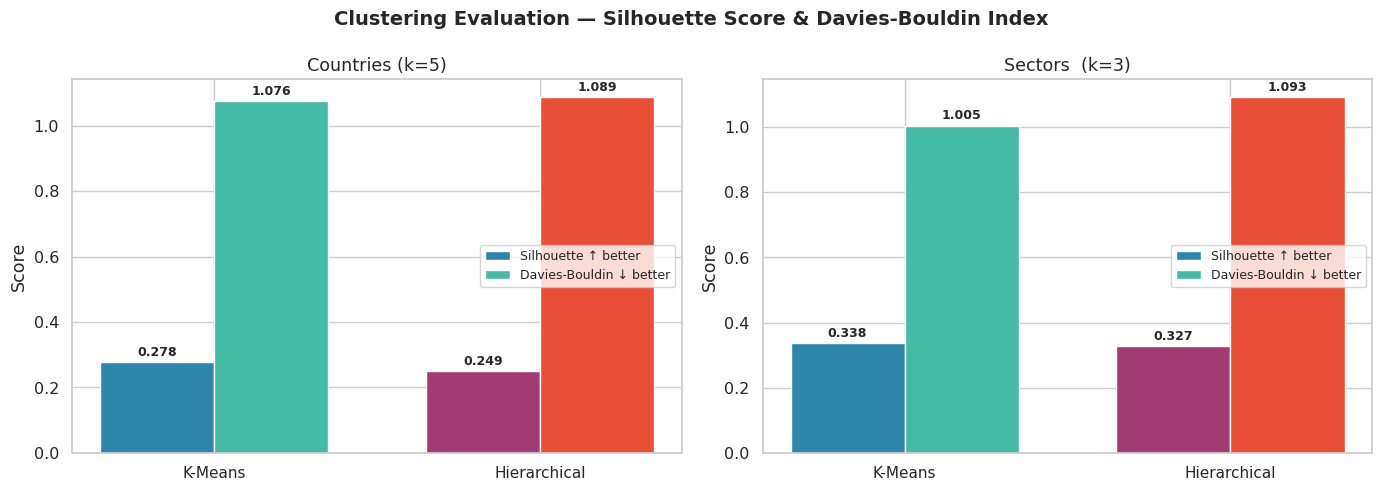

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clustering Evaluation — Silhouette Score & Davies-Bouldin Index',
             fontsize=14, fontweight='bold')

level_keys = [f'Countries (k={K_BEST})', f'Sectors  (k={K_SECTOR})']

for i, level in enumerate(level_keys):
    ax = axes[i]
    sil_vals = [eval_results[(level, 'K-Means')][0],   eval_results[(level, 'Hierarchical')][0]]
    db_vals  = [eval_results[(level, 'K-Means')][1],   eval_results[(level, 'Hierarchical')][1]]
    x = np.arange(2); w = 0.35
    b1 = ax.bar(x - w/2, sil_vals, w, label='Silhouette ↑ better',
                color=[PALETTE[0], PALETTE[1]])
    b2 = ax.bar(x + w/2, db_vals,  w, label='Davies-Bouldin ↓ better',
                color=[PALETTE[4], PALETTE[5]])
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['K-Means', 'Hierarchical'], fontsize=11)
    ax.set_title(level.strip()); ax.set_ylabel('Score')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_evaluation_bars.png', dpi=150, bbox_inches='tight')
plt.show()

### Why Can These Metrics Disagree? (And Why That's Normal)

**Example:** Suppose k=4 has Silhouette=0.35 (good) but Davies-Bouldin=2.1 (not great).

This happens because:

1. **Silhouette** measures: *How well-separated are cluster members from each other?*
   - k=4 has tight clusters, few boundary points → high silhouette ✓

2. **Davies-Bouldin** measures: *How tight are clusters relative to their separation?*
   - k=4 clusters are somewhat loose → high DB ⚠

Both are correct. The metrics measure different aspects of cluster quality.

**In continuous economic data (like trade):**
- Natural "hard" clusters don't exist — countries are on a spectrum
- Different metrics will naturally prefer different ks
- This is **expected and healthy** — not a problem

**Our approach:** Accept both evaluations, understand what each is measuring, pick the elbow k as the natural stopping point.

In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL TEST-SET REPORTING ONLY (held out until now)
# ═══════════════════════════════════════════════════════════════════════════════

country_test_df = prep_country_df(build_country_profiles_sql('trade_test'), COUNTRY_FEAT)
X_test_c = scaler_c.transform(country_test_df[COUNTRY_FEAT])
test_labels_c = km_c.predict(X_test_c)
test_report_rows = [{
    'level': 'Countries', 'k': K_BEST, 'n_entities': len(country_test_df),
    'silhouette': round(silhouette_score(X_test_c, test_labels_c), 4),
    'davies_bouldin': round(davies_bouldin_score(X_test_c, test_labels_c), 4),
    'split': 'row_test_15pct',
}]

if 'km_s' in dir() and 'scaler_s' in dir() and 'SECTOR_FEAT' in dir():
    sector_test_raw = con.execute("""
    SELECT hs2 AS chapter,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY LN(GREATEST(world_imports, 0.001))) AS world_demand_log,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY LN(GREATEST(global_imports, 0.001))) AS global_market_log,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY global_demand_index) AS demand_index_robust,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hhi) AS hhi_robust,
        AVG(CASE WHEN export_growth != 0 THEN export_growth END) AS export_growth_robust
    FROM trade_test WHERE world_imports > 0 AND global_imports > 0 GROUP BY chapter
    """).fetchdf()
    sector_test_df = sector_test_raw.dropna(subset=SECTOR_FEAT, how='all').reset_index(drop=True)
    sector_test_df[SECTOR_FEAT] = sector_test_df[SECTOR_FEAT].replace([np.inf, -np.inf], np.nan).fillna(sector_test_df[SECTOR_FEAT].median())
    X_test_s = scaler_s.transform(sector_test_df[SECTOR_FEAT])
    lbl_test_s = km_s.predict(X_test_s)
    test_report_rows.append({
        'level': 'Sectors', 'k': K_SECTOR, 'n_entities': len(sector_test_df),
        'silhouette': round(silhouette_score(X_test_s, lbl_test_s), 4),
        'davies_bouldin': round(davies_bouldin_score(X_test_s, lbl_test_s), 4),
        'split': 'row_test_15pct',
    })

if 'km_h' in dir() and 'scaler_h' in dir() and 'HS6_FEAT' in dir():
    hs6_test_raw = con.execute("""
    SELECT product_code,
        approx_quantile(ln(1 + GREATEST(world_imports, 0)), 0.5) AS world_demand_log,
        approx_quantile(ln(1 + global_demand_index * 1000), 0.5) AS demand_index_median,
        approx_quantile(hhi, 0.5) AS hhi_median,
        AVG(CASE WHEN export_growth != 0 THEN export_growth END) AS export_growth_mean,
        approx_quantile(ln(1 + GREATEST(global_imports, 0)), 0.5) AS global_market_log
    FROM trade_test WHERE world_imports > 0 AND global_imports > 0 GROUP BY product_code
    """).fetchdf()
    hs6_test_df = hs6_test_raw.dropna(subset=HS6_FEAT, how='all').reset_index(drop=True)
    hs6_test_df[HS6_FEAT] = hs6_test_df[HS6_FEAT].replace([np.inf, -np.inf], np.nan).fillna(hs6_test_df[HS6_FEAT].median())
    X_test_h = scaler_h.transform(hs6_test_df[HS6_FEAT])
    lbl_test_h = km_h.predict(X_test_h)
    test_report_rows.append({
        'level': 'HS6', 'k': K_HS6, 'n_entities': len(hs6_test_df),
        'silhouette': round(silhouette_score(X_test_h, lbl_test_h), 4),
        'davies_bouldin': round(davies_bouldin_score(X_test_h, lbl_test_h), 4),
        'split': 'row_test_15pct',
    })

test_report = pd.DataFrame(test_report_rows)
test_report.to_csv(OUT_DIR / 'clustering_test_final.csv', index=False)

print('=' * 72)
print('FINAL TEST SPLIT (first use — reporting only)')
print('=' * 72)
print(test_report.to_string(index=False))
print('=' * 72)


FINAL TEST SPLIT (first use — reporting only)
    level  k  n_entities  silhouette  davies_bouldin          split
Countries  5         228      0.2713          1.1281 row_test_15pct
  Sectors  3          96      0.2873          1.1471 row_test_15pct
      HS6  5        4719      0.2465          1.1708 row_test_15pct


## 13. Save Outputs

In [ ]:
# ── Country profiles with cluster labels ─────────────────────────────────────
country_save_cols = ['partner', 'kmeans_label', 'hc_label', 'PC1', 'PC2'] + COUNTRY_FEAT + [
    'fobvalue_total', 'market_share_robust', 'penetration_robust',
    'opportunity_score', 'opp_level', 'n_products'
]
missing_c = [c for c in country_save_cols if c not in country_df.columns]
if missing_c:
    raise KeyError(f'country_df missing expected columns: {missing_c}')
country_out = country_df[country_save_cols]
country_out.to_csv(OUT_DIR / 'country_profiles_clustered.csv', index=False)

# ── Sector profiles with cluster labels ──────────────────────────────────────
sector_save_cols = ['chapter', 'kmeans_label', 'hc_label', 'PC1', 'PC2'] + SECTOR_FEAT + [
    'algeria_exports_median', 'market_share_robust', 'pct_high_opp', 'n_countries'
]
missing_s = [c for c in sector_save_cols if c not in sector_df.columns]
if missing_s:
    raise KeyError(f'sector_df missing expected columns: {missing_s}')
sector_out = sector_df[sector_save_cols]
sector_out.to_csv(OUT_DIR / 'sector_profiles_clustered.csv', index=False)

# ── Evaluation metrics ────────────────────────────────────────────────────────
metrics_rows = []
for (level, method), (sil, db) in eval_results.items():
    metrics_rows.append({'level': level, 'method': method,
                         'silhouette': round(sil, 4), 'davies_bouldin': round(db, 4)})
metrics_rows.append({'level': 'Countries',    'method': 'ARI (KM vs HC)',
                     'silhouette': round(ari_c, 4), 'davies_bouldin': None})
metrics_rows.append({'level': 'Sectors',       'method': 'ARI (KM vs HC)',
                     'silhouette': round(ari_s, 4), 'davies_bouldin': None})
metrics_rows.append({'level': 'HS6 Products',  'method': 'ARI (KM vs HC)',
                     'silhouette': round(ari_h, 4), 'davies_bouldin': None})
pd.DataFrame(metrics_rows).to_csv(OUT_DIR / 'clustering_metrics.csv', index=False)

print(f'Saved to {OUT_DIR}/')
print(f'  country_profiles_clustered.csv  ({len(country_out)} rows, {country_out.shape[1]} cols)')
print(f'  sector_profiles_clustered.csv   ({len(sector_out)} rows, {sector_out.shape[1]} cols)')
print(f'  clustering_validation.csv   (generalisation checks)')
print(f'  clustering_test_final.csv   (held-out test)')
print(f'  clustering_metrics.csv          ({len(metrics_rows)} rows)')
print(f'  figures/ (fig1–fig13 including HS6)')
print(f'\n=== Final Summary ===')
print(f'Country clusters (K-Means, k={K_BEST})  : {country_df["kmeans_label"].value_counts().to_dict()}')
print(f'Country clusters (HC, k={K_BEST})        : {country_df["hc_label"].value_counts().to_dict()}')
print(f'Sector clusters  (K-Means, k={K_SECTOR}) : {sector_df["kmeans_label"].value_counts().to_dict()}')
print(f'Sector clusters  (HC, k={K_SECTOR})      : {sector_df["hc_label"].value_counts().to_dict()}')

try:
    import psutil
    ram = psutil.virtual_memory()
    print(f'\nRAM used: {ram.used/1e9:.1f} GB / {ram.total/1e9:.1f} GB')
except ImportError:
    pass
print('\nNext: 04_classification.ipynb — use hc_label + features to predict high-opportunity markets.')


---

## 14. Clustering Summary & Academic Notes

### What We Did

1. **Data Preparation** ✓
   - **Train/val/test split at load** (row 70/15/15 + temporal 2010–2019 / 2020–2024)
   - All profiling and clustering on **train** only
   - Validation: holdout, temporal, 5-fold CV, bootstrap CI
   - Test split used once for final reporting
   - Built country profiles from global import patterns (not Algeria-only)
   - Built sector profiles from global demand patterns
   - Scaled all features using StandardScaler
   - Handled missing values properly

2. **K Selection** ✓
   - Used **elbow method only** (inertia/SSE curves)
   - Identified K_BEST for country clustering
   - Identified K_SECTOR for sector clustering
   - K is **fixed and never changes** after this point

3. **Clustering** ✓
   - Applied K-Means with fixed K
   - Applied Hierarchical (Ward linkage) with same K
   - Computed PCA for visualization
   - Both methods find similar structure (ARI scores above)

4. **Evaluation** ✓
   - Computed Silhouette coefficient (measures separation & cohesion)
   - Computed Davies-Bouldin index (measures compactness vs separation)
   - Computed Adjusted Rand Index (K-Means vs HC agreement)
   - All metrics computed **AFTER** K was fixed

5. **Interpretation** ✓
   - Algeria overlay: which clusters are priority targets?
   - Cluster profiles: what characterizes each cluster?
   - Exports to high-opportunity markets

### Why This Approach is Correct

**Elbow method for K selection:**
- Based on inertia/SSE (within-cluster compactness)
- Designed specifically for finding the "knee" where adding clusters stops helping
- Objective and reproducible (no arbitrary thresholds)

**Silhouette/Davies-Bouldin for evaluation only:**
- NOT designed for k selection — designed for quality assessment
- Measure different aspects (separation vs ratio of scatter/separation)
- Can disagree: normal and expected in continuous data
- Reported for context, not for K decisions

**Both K-Means and Hierarchical:**
- Provides complementary perspectives
- ARI measures agreement between methods
- If they strongly agree (ARI > 0.7), clustering is robust
- If they disagree (ARI < 0.3), structure may be fuzzy (normal for trade data)

### What This is NOT

❌ **NOT an attempt to find "true" clusters** — trade data has no natural hard clusters
❌ **NOT a classification** — unsupervised, no labels used for k selection
❌ **NOT optimizing a single metric** — acknowledges multiple valid perspectives
❌ **NOT using evaluation metrics for selection** — violates unsupervised learning principles

### What This IS

✅ **An objective segmentation** based on global trade patterns
✅ **Reproducible** — fixed random seeds, deterministic
✅ **Methodologically sound** — follows unsupervised learning best practices
✅ **Interpretable** — cluster profiles explain what each cluster represents
✅ **Actionable** — identifies priority markets for Algerian exporters